## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import random

from scipy import stats
from scipy.stats import pearsonr
from wordfreq import zipf_frequency

from flow_tree_utils import (
    steiger_z_test,
    get_matched_random_walk,
    generate_flow_tree_from_trajs,
    plot_flow_tree,
)

### Load wikispeedia data, etc

In [2]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        article_names.append(line)
print(f"{len(article_names)} nodes/articles loaded.")

# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(
    f"{data_path}/links.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
print(f"{len(edges_df)} edges/hyperlinks loaded.")

wikiG = nx.DiGraph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))
print(wikiG)

4604 nodes/articles loaded.
119881 edges/hyperlinks loaded.
DiGraph with 4592 nodes and 119881 edges


In [3]:
### Load trajectories
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print(f"{trajs_df.shape[0]} trajectories before dupes removed")
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print(f"Final data has {trajs_df.shape[0]} trajectories")
print(
    f"\twith {len(trajs_df.StartAt.unique())} unique starts and {len(trajs_df.EndAt.unique())} unique ends"
)
print(f"\tand {len(trajs_df.hashedIpAddress.unique())} unique players")


def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "__" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]].head()

76193 trajectories before dupes removed
Final data has 70770 trajectories
	with 4168 unique starts and 3997 unique ends
	and 20868 unique players


,StartEnd,traj,accuracy,avg_rating
0,14th_century__African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century__African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century__African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century__Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century__John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0


## 2. Helper fns
to make below less gross

In [4]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

stop_words = set(["a", "an", "the", "and", "for", "of"])

node_indegrees = {}
node_outdegrees = {}
node_zipf_frequencies = {}
for node in node_counts:
    if node in wikiG:
        node_indegrees[node] = wikiG.in_degree(node)
        node_outdegrees[node] = wikiG.out_degree(node)
        node_zipf_frequencies[node] = np.mean(
            [
                zipf_frequency(word, "en")
                for word in node.split("_")
                if word not in stop_words
            ]
        )


# find most common nodes
def find_k_most_x_nodes(
    node_value_dict, k=100, restrict_to=None, actually_most=True, verbose_str=None
):
    if restrict_to is None:
        restrict_to = node_value_dict.keys()
    most_x_nodes = sorted(
        [x for x in restrict_to],
        key=lambda x: node_value_dict[x],
        reverse=actually_most,
    )[:k]

    if verbose_str:
        print(
            f"{'Most' if actually_most else 'Least'} {verbose_str} node is {most_x_nodes[0]} with {node_value_dict[most_x_nodes[0]]}; "
            f"{k}th {'most' if actually_most else 'least'} is {most_x_nodes[-1]} with {node_value_dict[most_x_nodes[-1]]}"
        )
    return most_x_nodes

In [5]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# pip install "tokenizers<0.22" --force-reinstall
model_name = "bert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


def embed(text):
    tokens = tok(text.replace("_", " "), return_tensors="pt", truncation=True)
    out = model(**tokens)
    # mean pooling
    emb = out.last_hidden_state.mean(dim=1)
    return emb.detach()


def cosine(a, b):
    return F.cosine_similarity(a, b).item()


def get_topic_distance(topic1, topic2):
    return cosine(embed(topic1), embed(topic2))


get_topic_distance("the_dog", "the_cat")

0.9181366562843323

In [6]:
embeddings_dict = {node: embed(node) for node in node_counts}

In [7]:
degree_cache = {}
zipf_cache = {}
cosine_cache = {}

In [8]:
def get_weighted_matched_random_walk(
    G, start_node, walk_length, weights, degree_cache=degree_cache
):
    trajectory = [start_node]
    current_node = start_node

    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))

        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        elif len(neighbors) == 1:
            current_node = neighbors[0]
        else:
            # if current_node in degree_cache:
            #     # print("using cache")
            #     these_weights = degree_cache[current_node]
            # else:
            # print("adding to cache", current_node)
            these_weights = [weights[n] for n in neighbors]
            # degree_cache[current_node] = these_weights
            try:
                current_node = random.choices(neighbors, these_weights, k=1)[0]
            except:
                print(these_weights)
        trajectory.append(current_node)

    return trajectory


def get_targeted_matched_random_walk(G, start_node, target, walk_length):
    trajectory = [start_node]
    current_node = start_node

    # print(start_node, target)
    # print(walk_length)

    # TODO: this should be based on similariyt to target youa re so stupid
    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))
        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        else:
            if current_node in cosine_cache:
                # print("using cache")
                weights = cosine_cache[current_node]
            else:
                weights = []
                for n in neighbors:
                    w1 = embeddings_dict.get(n, embed(n))
                    if n not in embeddings_dict:
                        embeddings_dict[n] = w1

                    w2 = embeddings_dict.get(current_node, embed(current_node))
                    if current_node not in embeddings_dict:
                        embeddings_dict[current_node] = w2
                    dist = cosine(w1, w2)
                    weights.append(dist)
                cosine_cache[current_node] = weights
                print("added to cache", current_node)

            current_node = random.choices(neighbors, weights, k=1)[0]
        trajectory.append(current_node)
    return trajectory

In [9]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

word_frequency_centrality = {}
for node in wikiG.nodes():
    word_frequency_centrality[node] = np.mean(
        [zipf_frequency(word, "en") for word in node.split("_")]
    )
print("Word Frequency Centrality:", word_frequency_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.005009801786103245, 'D%C3%A1l_Riata': 0.006970159006752342, 'Great_Britain': 0.0468307558266173, 'Ireland': 0.08494881289479417, 'Isle_of_Man': 0.021128294489218036, 'Monarchy': 0.04356349379220214, 'Orkney': 0.013286865606621652, 'Picts': 0.00958396863428447, 'Scotland': 0.0980178610324548, 'Wales': 0.0490089305162274, '%C3%85land': 0.004138531910259203, '20th_century': 0.08690917011544326, 'Baltic_Sea': 0.024177739054672187, 'Crimean_War': 0.012197778261816599, 'Currency': 0.06817686778479634, 'Euro': 0.03201916793726857, 'European_Union': 0.08298845567414508, 'Finland': 0.04966238292311043, 'League_of_Nations': 0.029840993247658463, 'List_of_countries_by_system_of_government': 0.09867131343933784, 'Nationality': 0.00936615116532346, 'Parliamentary_system': 0.02940535830973644, 'Police': 0.021128294489218036, 'Russia': 0.13613591810063166, 'Stockholm': 0.013722500544543673, 'Sweden': 0.0847309

In [10]:
def make_traj_dict(node_list, trajs_df, min_path_length=5):
    traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(len(traj) - min_path_length - 1):  # want min path length 5?
            if traj[i] in node_list:
                traj_dict[traj[i]].append(traj[i : i + min_path_length])
    return traj_dict


def make_rev_traj_dict(node_list, trajs_df, min_path_length=5):
    rev_traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(min_path_length, len(traj)):  # want min path length 7?
            if traj[i] in node_list:
                rev_traj = [x for x in reversed(traj[i - min_path_length : i])]
                rev_traj_dict[traj[i]].append(rev_traj)
    return rev_traj_dict


def sample_flow_trees_from_traj_dict(traj_dict, wikiG, k_fold=5, traj_per_tree=20):
    flow_tree_dict = {}
    for node in traj_dict:
        trees = []
        random_trees, weighted_random_trees, targeted_random_trees = [], [], []
        for _ in range(k_fold):
            sampled_trajs = traj_dict[node]
            if len(sampled_trajs) > traj_per_tree:
                sampled_indices = np.random.choice(
                    len(sampled_trajs), size=traj_per_tree, replace=False
                )
                sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
            # else:
            #     print(len(sampled_trajs))
            G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
            new_G = nx.relabel.convert_node_labels_to_integers(
                G, first_label=0, ordering="default"
            )
            trees.append(new_G)

            # using random data
            if sampled_trajs[0][0] in wikiG:
                # print("making random trajs")
                random_trajs = [
                    get_matched_random_walk(
                        wikiG, sampled_trajs[0][0], len(sampled_trajs[i])
                    )
                    for i in range(len(sampled_trajs))
                ]
                random_weighted_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        degree_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]
                # print("dc", len(degree_cache))

                random_semantic_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        word_frequency_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]

                # [get_targeted_matched_random_walk(
                #     wikiG, sampled_trajs[0][0], sampled_trajs[i][-1], len(sampled_trajs[i])
                # ) for i in range(len(sampled_trajs))]
                # print("cc", len(cosine_cache))
                # print("done")

                random_G = generate_flow_tree_from_trajs(random_trajs, END_NODE="1")
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                random_trees.append(new_G)

                weighted_random_G = generate_flow_tree_from_trajs(
                    random_weighted_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    weighted_random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                weighted_random_trees.append(new_G)

                random_G = generate_flow_tree_from_trajs(
                    random_semantic_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                targeted_random_trees.append(new_G)

                # print("done making trees")
        flow_tree_dict[node] = {
            "human": trees,
            "random": random_trees,
            "weighted_random": weighted_random_trees,
            "targeted_random": targeted_random_trees,
        }
    return flow_tree_dict

In [11]:
def plot_some_from_flow_tree_dict(flow_tree_dict, title_str=""):
    n_cols = 6
    fig, axes = plt.subplots(4, n_cols, figsize=(20, 8))
    for j, node in enumerate(flow_tree_dict):
        G = flow_tree_dict[node]["human"][0]
        ax = axes[0][j]
        plot_flow_tree(G, f"HUMAN init at {node}", ax, just_edges=True, no_title=False)

        random_G = flow_tree_dict[node]["random"][0]
        ax = axes[1][j]
        plot_flow_tree(
            random_G, f"RANDOM init at {node}", ax, just_edges=True, no_title=False
        )

        random_G = flow_tree_dict[node]["weighted_random"][0]
        ax = axes[2][j]
        plot_flow_tree(
            random_G,
            f"WEIGHTED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        random_G = flow_tree_dict[node]["targeted_random"][0]
        ax = axes[3][j]
        plot_flow_tree(
            random_G,
            f"TARGETED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        if j == n_cols - 1:
            break
    plt.suptitle(title_str)
    plt.tight_layout()
    plt.show()

In [12]:
def make_flow_tree_dict_from_node_list(
    node_list,
    trajs_df,
    min_path_length=7,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=20,
    plot_title_str=None,
):
    traj_dict = make_traj_dict(node_list, trajs_df, min_path_length=min_path_length)
    flow_tree_dict = sample_flow_trees_from_traj_dict(
        traj_dict, wikiG, k_fold=k_fold, traj_per_tree=traj_per_tree
    )

    if plot_title_str:
        plot_some_from_flow_tree_dict(flow_tree_dict, title_str=plot_title_str)

    return flow_tree_dict

In [13]:
def tree_depth(graph, root=0):
    depths = nx.single_source_shortest_path_length(graph, root)
    return max(depths.values())


def branching_factor(graph):
    branching_factors = [
        len(list(graph.neighbors(node)))
        for node in graph.nodes()
        if graph.degree(node) != 1
    ]
    return np.mean(branching_factors)


def root_degree(graph, root=0):
    return graph.degree[root]


def extract_tree_features(G, root=0):
    num_nodes = G.number_of_nodes()
    num_leaves = sum(1 for node in G.nodes() if G.degree(node) == 1)
    depth = tree_depth(G, root)
    diameter = nx.diameter(G)
    bf = branching_factor(G)
    rd = root_degree(G, root)

    return [
        num_nodes,
        num_leaves,
        depth,
        diameter,
        bf,
        rd,
    ]


def run_ttests_on_flow_tree_groups(
    group1_trees,
    group2_trees,
    normalise=False,
    group1_name="Group 1",
    group2_name="Group 2",
):
    results_df = pd.DataFrame(
        columns=[
            "group1_name",
            "group2_name",
            "group1_mean",
            "group2_mean",
            "group1_var",
            "group2_var",
            "group1_n",
            "group2_n",
            "statistic",
            "p_value",
            "metric",
            "notes",
        ]
    )

    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "diameteravg_branching_factor",
        "root_degree",
    ]

    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        # T-test
        t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
        results_df.loc[len(results_df)] = {
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_feature),
            "group2_mean": np.mean(group2_feature),
            "group1_var": np.var(group1_feature),
            "group2_var": np.var(group2_feature),
            "group1_n": len(group1_feature),
            "group2_n": len(group2_feature),
            "statistic": t_stat,
            "p_value": p_val,
            "metric": feature_name,
            "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
        }

    return results_df, group1_features, group2_features

## 3. Idk make Flow Trees?

In [14]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
most_indegree_nodes = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)
least_indegree_nodes = find_k_most_x_nodes(
    node_indegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="indegree",
)
most_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
least_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="outdegree",
)

print()
print(
    "Most outdegree, most indegree overlap",
    len(set(most_indegree_nodes).intersection(set(most_outdegree_nodes))),
)
print(
    "Least outdegree, least indegree overlap",
    len(set(least_indegree_nodes).intersection(set(least_outdegree_nodes))),
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most indegree node is United_States with 1551; 50th most is Brazil with 261
Least indegree node is Education_in_the_United_States with 3; 50th least is Penguin with 26
Most outdegree node is United_States with 294; 50th most is NATO with 96
Least outdegree node is Animation with 3; 50th least is Pyramid with 17

Most outdegree, most indegree overlap 20
Least outdegree, least indegree overlap 16


In [15]:
len(degree_cache)

0

In [16]:
len(cosine_cache)

0

In [17]:
most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=6,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=15,
    plot_title_str=None,
)

Most indegree:


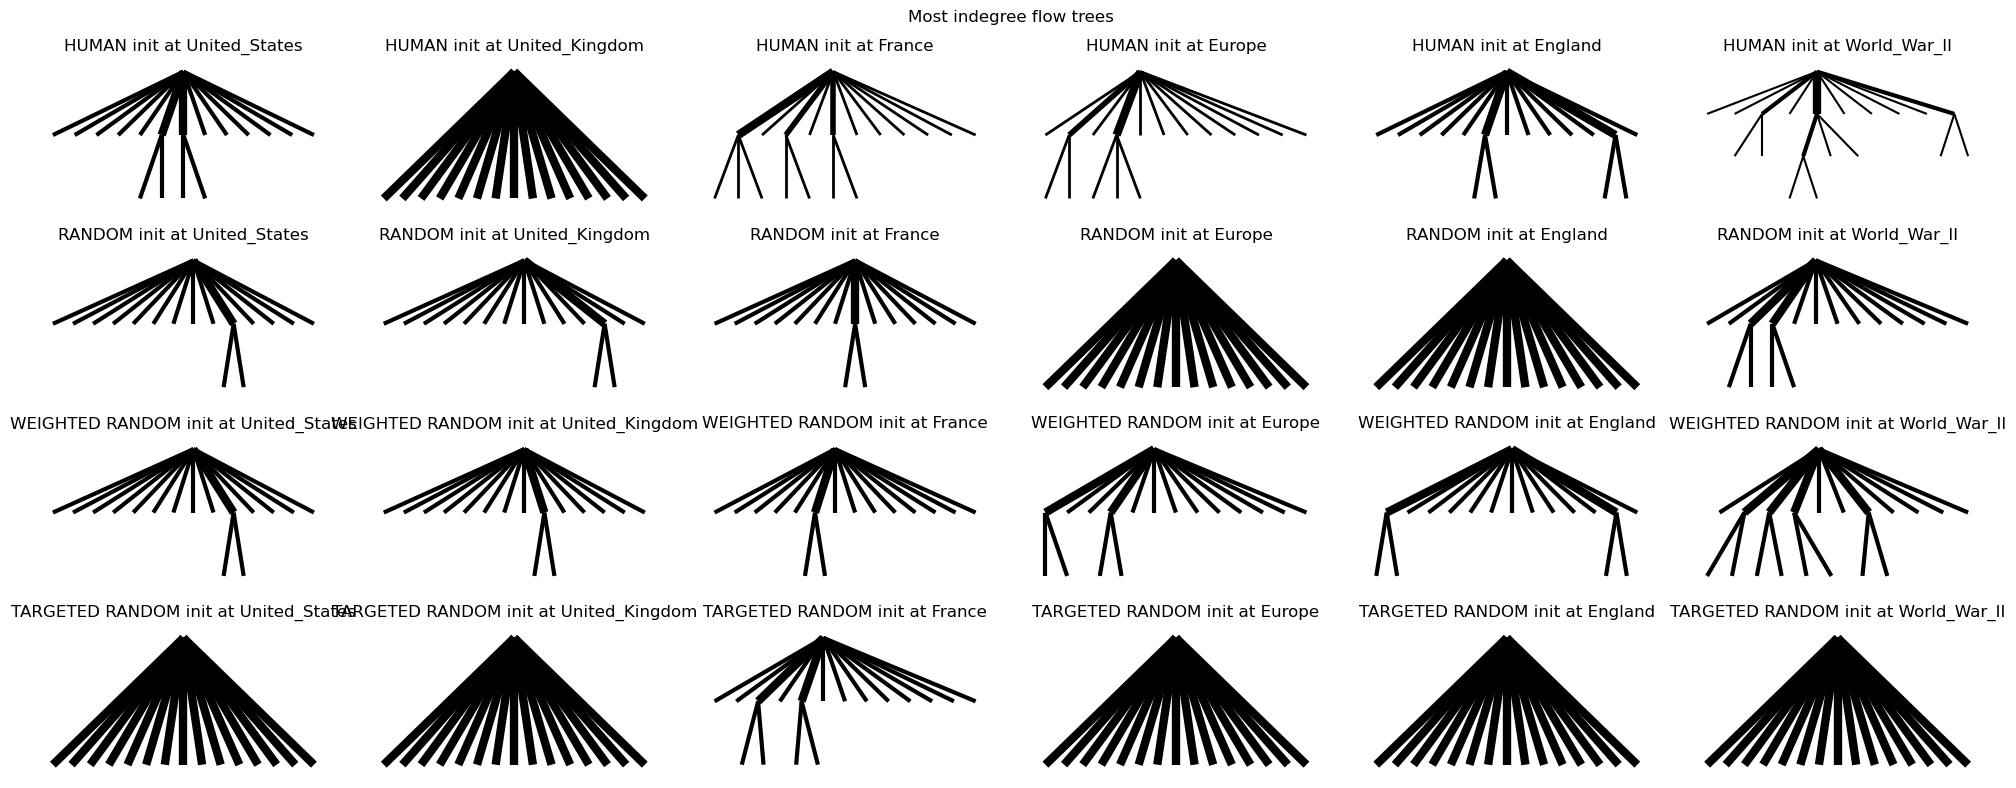

Least indegree:


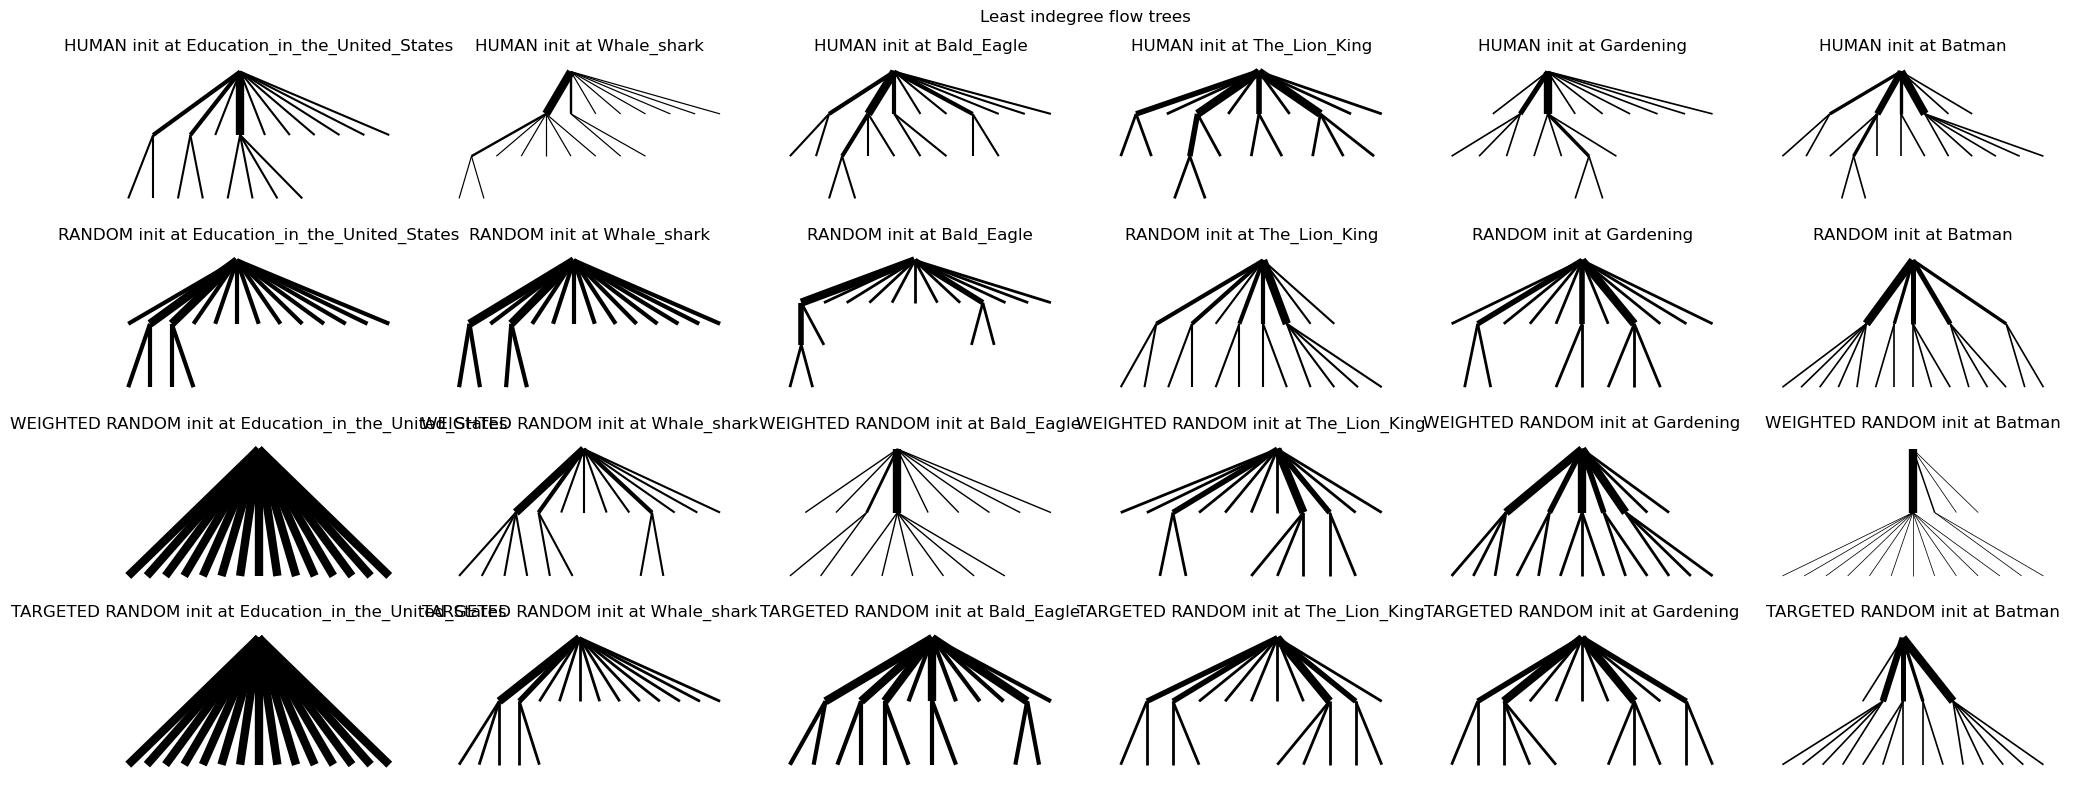

In [18]:
print("Most indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_indegree_nodes},
    title_str="Most indegree flow trees",
)
print("Least indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_indegree_nodes},
    title_str="Least indegree flow trees",
)

Most outdegree:


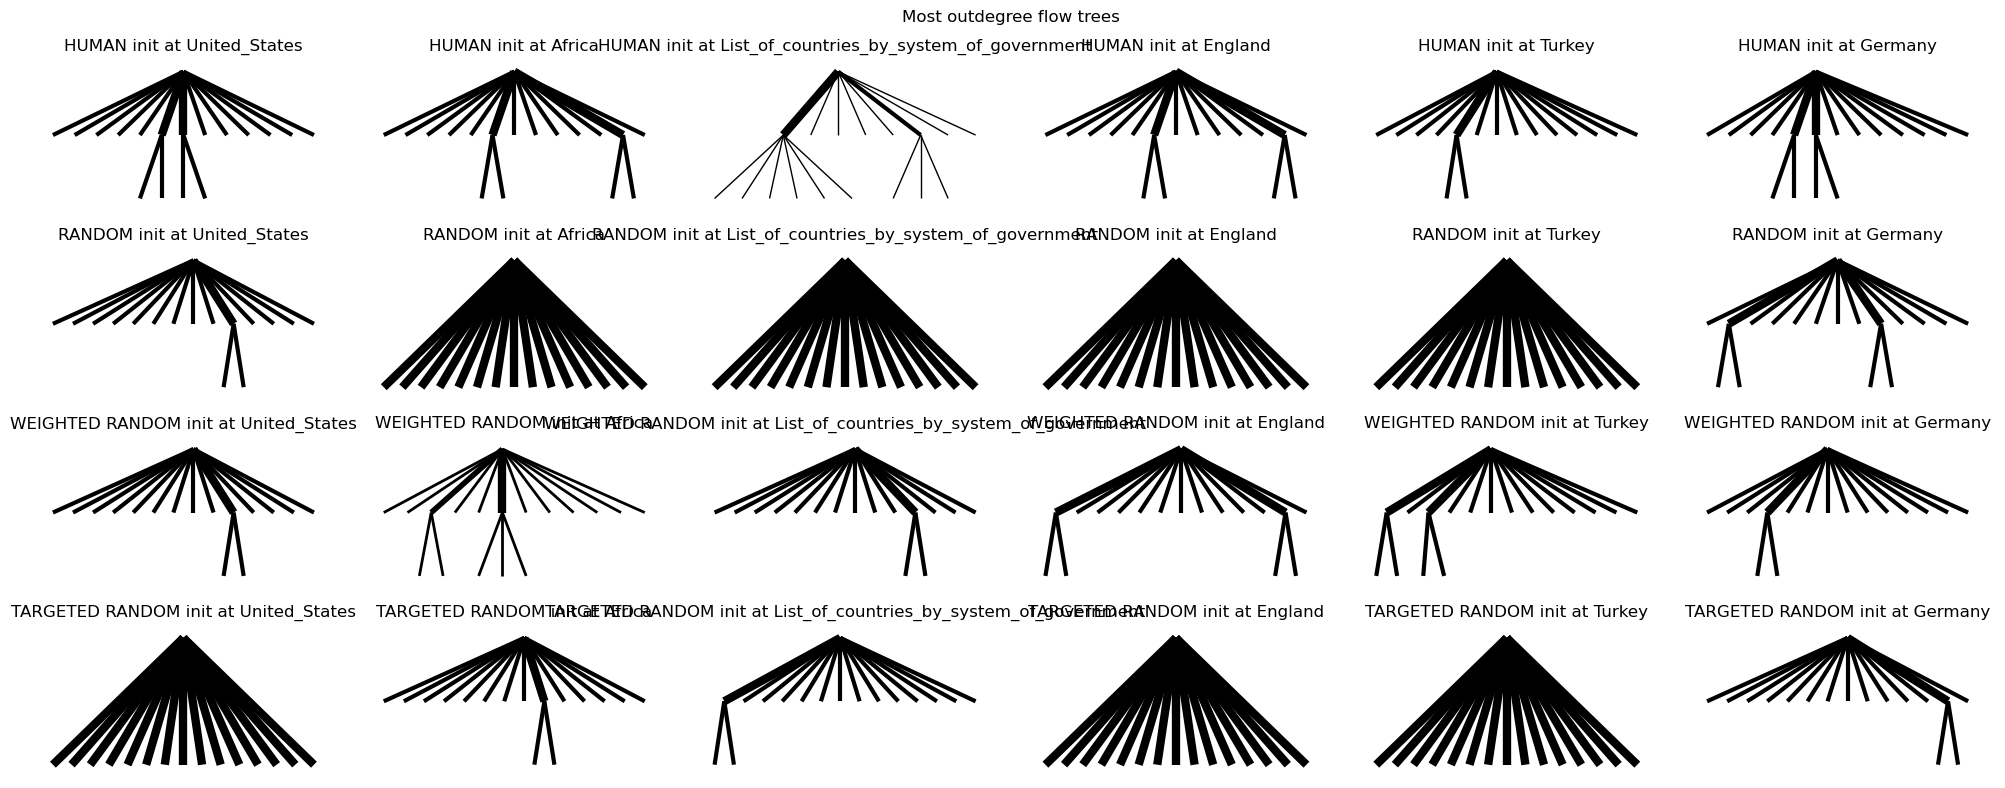

Least outdegree:


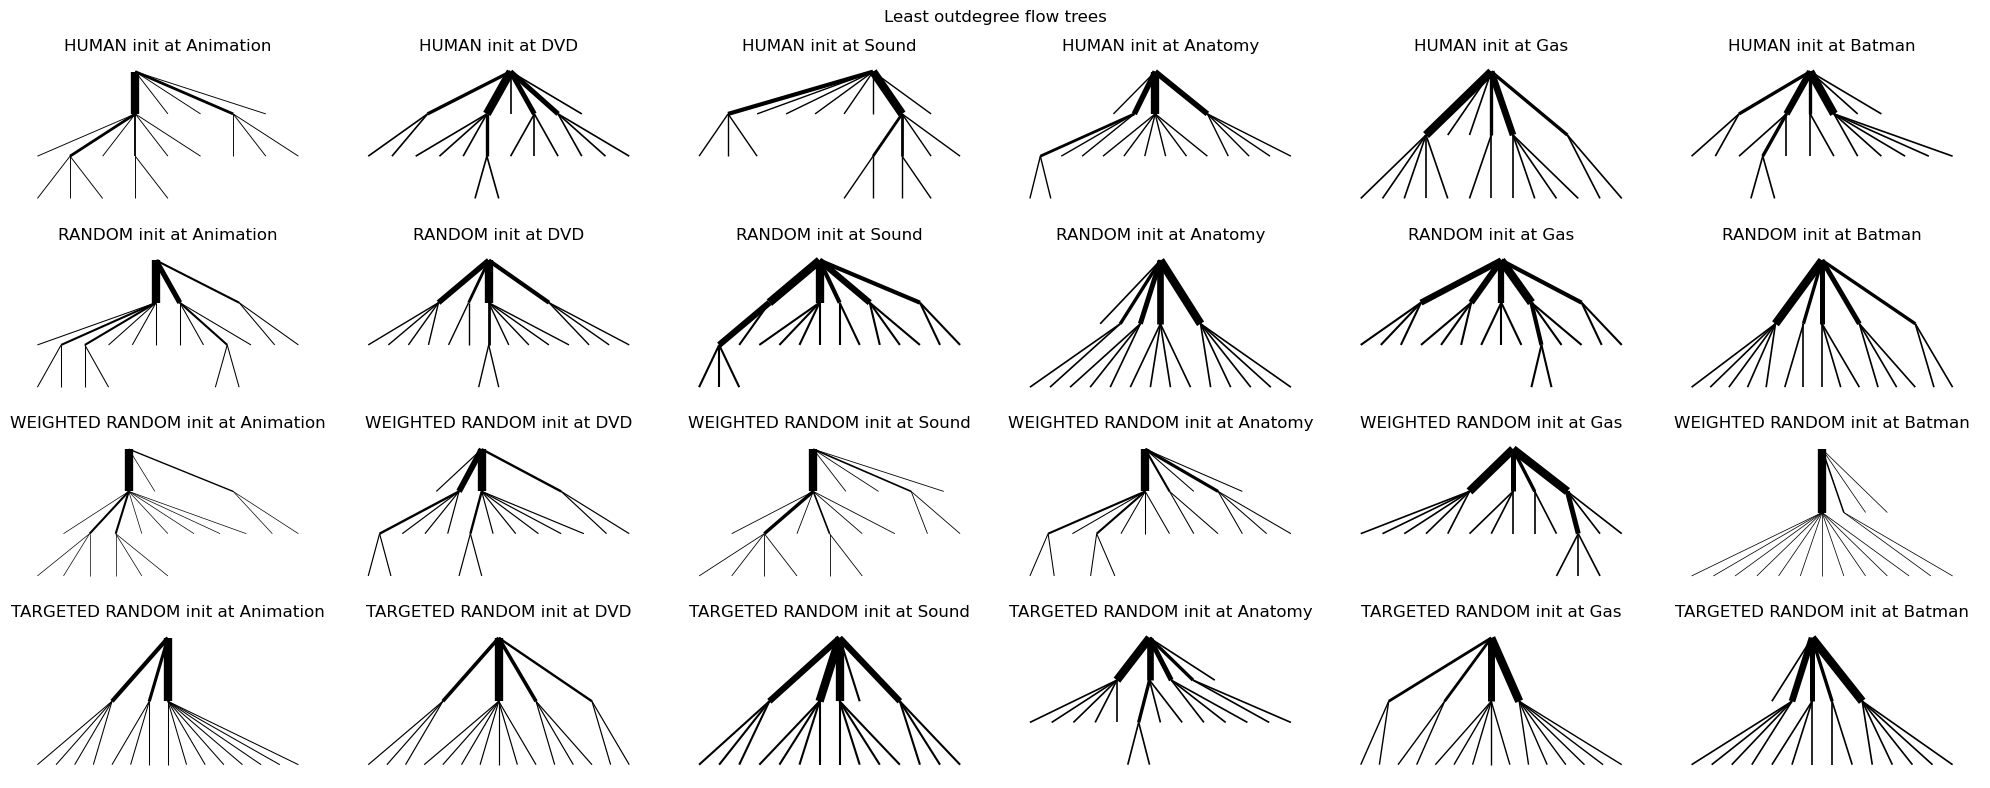

In [19]:
print("Most outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_outdegree_nodes},
    title_str="Most outdegree flow trees",
)
print("Least outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_outdegree_nodes},
    title_str="Least outdegree flow trees",
)

In [20]:
human_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_most_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human most outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human most outdegree,random most outdegree,18.360000,16.764000,1.318400,0.596304,250,250,18.200434,4.052664e-57,num_nodes,Comparing flow tree num_nodes between human mo...
1,human most outdegree,random most outdegree,14.976000,15.000000,0.023424,0.000000,250,250,-2.474460,1.367583e-02,num_leaves,Comparing flow tree num_leaves between human m...
2,human most outdegree,random most outdegree,2.120000,1.576000,0.185600,0.244224,250,250,13.093424,7.156270e-34,depth,Comparing flow tree depth between human most o...
3,human most outdegree,random most outdegree,3.876000,2.744000,0.508624,0.526464,250,250,17.557289,4.555245e-54,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,human most outdegree,random most outdegree,6.462762,10.870333,4.549081,13.201548,250,250,-16.507913,3.796474e-49,root_degree,Comparing flow tree root_degree between human ...


In [21]:
human_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    random_least_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="random least outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human least outdegree,random least outdegree,20.28000,20.568000,1.473600,1.021376,250,250,-2.877127,4.185381e-03,num_nodes,Comparing flow tree num_nodes between human le...
1,human least outdegree,random least outdegree,14.95600,15.000000,0.058064,0.000000,250,250,-2.881369,4.130376e-03,num_leaves,Comparing flow tree num_leaves between human l...
2,human least outdegree,random least outdegree,2.63600,2.244000,0.295504,0.184464,250,250,8.928523,8.330483e-18,depth,Comparing flow tree depth between human least ...
3,human least outdegree,random least outdegree,4.79600,4.280000,0.602384,0.273600,250,250,8.699640,4.875814e-17,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,human least outdegree,random least outdegree,4.56883,4.417876,0.410777,0.225386,250,250,2.986483,2.961084e-03,root_degree,Comparing flow tree root_degree between human ...


In [22]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    human_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="human most outdegree",
)
results_df[
    (results_df.group1_mean > results_df.group2_mean) & (results_df.p_value < 0.05)
][["group2_mean", "group1_mean", "metric"]]

,group2_mean,group1_mean,metric
0,18.360,20.280,num_nodes
2,2.120,2.636,depth
3,3.876,4.796,diameteravg_branching_factor


In [23]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    random_least_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="random least outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,random least outdegree,random most outdegree,20.568000,16.764000,1.021376,0.596304,250,250,47.194770,6.121168e-186,num_nodes,Comparing flow tree num_nodes between random l...
1,random least outdegree,random most outdegree,15.000000,15.000000,0.000000,0.000000,250,250,NaN,NaN,num_leaves,Comparing flow tree num_leaves between random ...
2,random least outdegree,random most outdegree,2.244000,1.576000,0.184464,0.244224,250,250,16.099244,2.971430e-47,depth,Comparing flow tree depth between random least...
3,random least outdegree,random most outdegree,4.280000,2.744000,0.273600,0.526464,250,250,27.097456,4.887657e-100,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,random least outdegree,random most outdegree,4.417876,10.870333,0.225386,13.201548,250,250,-27.786663,2.601443e-103,root_degree,Comparing flow tree root_degree between random...


### Landmark testing

In [24]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
if "Wikipedia_Text_of_the_GNU_Free_Documentation_License" in most_common_nodes:
    most_common_nodes.remove("Wikipedia_Text_of_the_GNU_Free_Documentation_License")

outdegree_landmarks = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
player_landmarks = find_k_most_x_nodes(
    node_counts, k=small_k, restrict_to=most_common_nodes, verbose_str="common"
)
semantic_landmarks = find_k_most_x_nodes(
    node_zipf_frequencies, k=small_k, restrict_to=most_common_nodes, verbose_str="zipf"
)


print()
print(
    "Most outdegree, most player overlap",
    len(set(outdegree_landmarks).intersection(set(player_landmarks))),
)
print(
    "Most player, most zipf overlap",
    len(set(player_landmarks).intersection(set(semantic_landmarks))),
)
print(
    "Most outdegree, most zipf overlap",
    len(set(outdegree_landmarks).intersection(set(semantic_landmarks))),
)

print(
    set(outdegree_landmarks)
    .intersection(set(player_landmarks))
    .intersection(set(semantic_landmarks))
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most outdegree node is United_States with 294; 50th most is NATO with 96
Most common node is United_States with 12660; 50th most is Water with 1093
Most zipf node is Time with 6.29; 50th most is Black_Sea with 5.26

Most outdegree, most player overlap 20
Most player, most zipf overlap 8
Most outdegree, most zipf overlap 9
{'World_War_II', 'Human', 'United_States', 'South_America', 'London', 'Water'}


In [25]:
indegree_landmarks = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)

Most indegree node is United_States with 1551; 50th most is Brazil with 261


In [26]:
most_common_nodes = set(most_common_nodes)
outdegree_landmarks = set(outdegree_landmarks)
player_landmarks = set(player_landmarks)
semantic_landmarks = set(semantic_landmarks)
indegree_landmarks = set(indegree_landmarks)

In [27]:
min_path_length = 5
traj_per_tree = 15

most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=min_path_length,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=traj_per_tree,
    plot_title_str=None,
)

rev_wikiG = wikiG.reverse()
rev_traj_dict = make_rev_traj_dict(
    most_common_nodes, trajs_df, min_path_length=min_path_length
)
most_common_rev_flow_tree_dict = sample_flow_trees_from_traj_dict(
    rev_traj_dict, rev_wikiG, k_fold=5, traj_per_tree=traj_per_tree
)

### ft-landmarks

In [28]:
node_ft_scores = {}
for node in most_common_nodes:
    trees = most_common_flow_tree_dict.get(node, {}).get("human", [])
    if not trees:
        continue
    depths = [tree_depth(G, 0) for G in trees]
    bfs = [branching_factor(G) for G in trees]
    ft_score = np.mean(bfs) / max(np.mean(depths), 0.5)
    node_ft_scores[node] = ft_score

ft_landmarks = find_k_most_x_nodes(
    node_ft_scores, k=small_k, restrict_to=most_common_nodes, verbose_str="ft_score"
)
ft_landmarks = set(ft_landmarks)
ft_landmarks

Most ft_score node is Gold with 6.395833333333332; 50th most is Ancient_Greece with 3.275


{'21st_century',
 'Albert_Einstein',
 'Alchemy',
 'Aluminium',
 'Ancient_Greece',
 'Ancient_Rome',
 'Argentina',
 'Astronomy',
 'Australia',
 'Bird',
 'British_monarchy',
 'Byzantine_Empire',
 'China',
 'Coal',
 'England',
 'Finland',
 'France',
 'German_language',
 'Germany',
 'Gold',
 'Greece',
 'Holy_Roman_Empire',
 'India',
 'Iran',
 'Iron',
 'Latin_America',
 'Middle_Ages',
 'New_York_City',
 'Ottoman_Empire',
 'Periodic_table',
 'Petroleum',
 'Plant',
 'Poland',
 'President_of_the_United_States',
 'Protein',
 'Quantum_mechanics',
 'Rome',
 'Russia',
 'Slavery',
 'Star',
 'Sub-Saharan_Africa',
 'Sweden',
 'Switzerland',
 'The_Beatles',
 'The_Holocaust',
 'Turkey',
 'United_Kingdom',
 'United_Nations',
 'United_States',
 'Uranium'}

In [29]:
# all_subjs = test_df["Subject"].unique()
# subjs_group1 = np.random.choice(all_subjs, len(all_subjs) // 2)
# subjs_group2 = set(all_subjs) - set(subjs_group1)

# better_direction_accs = []
# worse_direction_accs = []
# for i in range(len(OBJECTS)):
#     for j in range(i + 1, len(OBJECTS)):
#         start_node, end_node = OBJECTS[i], OBJECTS[j]

#         accs1_df = test_df[
#             (test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)
#         ][["accuracy", "Subject"]]
#         accs2_df = test_df[
#             (test_df["StartAt"] == end_node) & (test_df["EndAt"] == start_node)
#         ][["accuracy", "Subject"]]

#         intersection_df = pd.merge(accs1_df, accs2_df, how="inner", on=["Subject"])

#         dir_select_df = intersection_df[intersection_df["Subject"].isin(subjs_group1)]
#         acc1 = np.mean(dir_select_df["accuracy_x"].astype(float))
#         acc2 = np.mean(dir_select_df["accuracy_y"].astype(float))
#         dir_1_better = acc1 > acc2

#         # Cross validation
#         cross_val_df = intersection_df[intersection_df["Subject"].isin(subjs_group2)]
#         accs1 = cross_val_df["accuracy_x"].astype(float)
#         accs2 = cross_val_df["accuracy_y"].astype(float)

#         acc1 = np.mean(accs1)
#         acc2 = np.mean(accs2)

#         if dir_1_better:  # end_node not in ("W", "N", "O") :
#             # continue
#             # better_direction_accs.extend(accs1)
#             # worse_direction_accs.extend(accs2)
#             better_direction_accs.append(acc1)
#             worse_direction_accs.append(acc2)
#         else:
#             # better_direction_accs.extend(accs2)
#             # worse_direction_accs.extend(accs1)
#             better_direction_accs.append(acc2)
#             worse_direction_accs.append(acc1)

# # Perform Mann-Whitney U test since we can't assume normal distribution
# # statistic, p_value = stats.mannwhitneyu(better_direction_accs, worse_direction_accs, alternative="less")
# statistic, p_value = stats.ttest_rel(better_direction_accs, worse_direction_accs)

# print(np.mean(better_direction_accs))
# print(np.mean(worse_direction_accs))
# print(f"{statistic} p={p_value}", len(better_direction_accs))

### Landmark vs. Non-Landmark Flow Tree Examples

In [37]:
def plot_n_trees(flow_trees):
    fig, axes = plt.subplots(2, len(flow_trees) // 2, figsize=(10, 5))
    axes = axes.flatten()
    for i, ft in enumerate(flow_trees):
        plot_flow_tree(ft, f"FT", axes[i], just_edges=True, no_title=False)
    plt.tight_layout()
    plt.show()

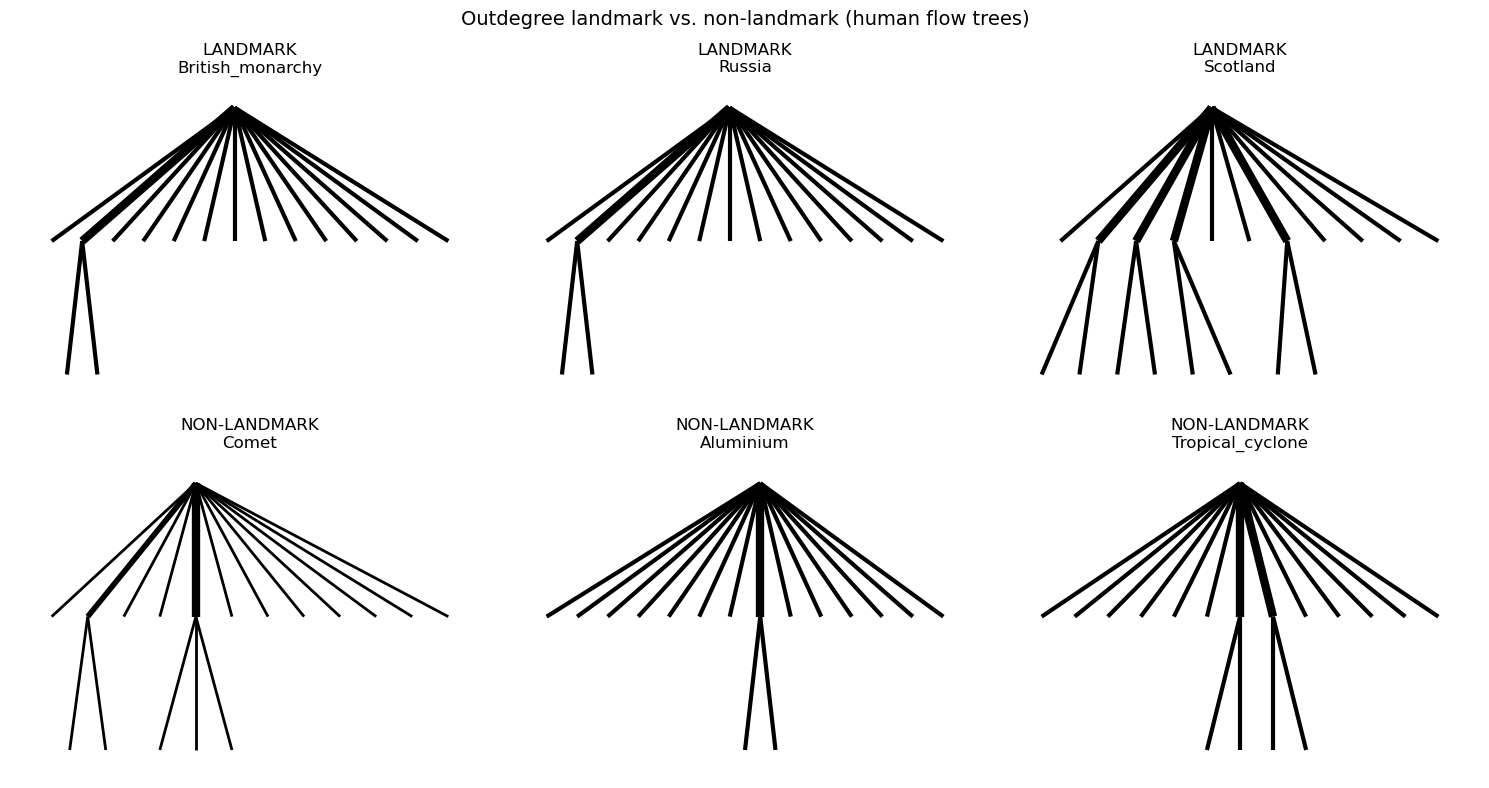

In [30]:
def plot_landmark_vs_nonlandmark(
    flow_tree_dict,
    landmark_nodes,
    all_nodes,
    landmark_type_str,
    n_examples=3,
    person="human",
):
    non_landmark_nodes = [n for n in all_nodes if n not in landmark_nodes]

    landmark_sample = random.sample(
        sorted(landmark_nodes), min(n_examples, len(landmark_nodes))
    )
    non_landmark_sample = random.sample(
        non_landmark_nodes, min(n_examples, len(non_landmark_nodes))
    )

    fig, axes = plt.subplots(2, n_examples, figsize=(5 * n_examples, 8))
    fig.suptitle(
        f"{landmark_type_str} landmark vs. non-landmark (human flow trees)", fontsize=14
    )

    for j, node in enumerate(landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"LANDMARK\n{node}", axes[0][j], just_edges=True, no_title=False
        )

    for j, node in enumerate(non_landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"NON-LANDMARK\n{node}", axes[1][j], just_edges=True, no_title=False
        )

    axes[0][0].set_ylabel("Landmark", fontsize=12)
    axes[1][0].set_ylabel("Non-Landmark", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_landmark_vs_nonlandmark(
    most_common_flow_tree_dict, outdegree_landmarks, most_common_nodes, "Outdegree"
)

# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, player_landmarks, most_common_nodes, "Player")
# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, semantic_landmarks, most_common_nodes, "Semantic")


In [31]:
def compute_asymmetry(forward_trees, reverse_trees):
    forward_bfs = []
    reverse_bfs = []

    # Branching Factor
    for tree in forward_trees:
        branching_factors = [
            len(list(tree.neighbors(node)))
            for node in tree.nodes()
            if tree.degree(node) != 1
        ]
        depth = tree_depth(tree, 0)
        ft_score = np.mean(branching_factors) / max(depth, 0.5)
        # forward_bfs.append(branching_factors[0])
        diam = nx.diameter(tree)
        forward_bfs.append(diam)

    for tree in reverse_trees:
        branching_factors = [
            len(list(tree.neighbors(node)))
            for node in tree.nodes()
            if tree.degree(node) != 1
        ]
        depth = tree_depth(tree, 0)
        ft_score = np.mean(branching_factors) / max(depth, 0.5)
        # reverse_bfs.append(np.mean(branching_factors))
        diam = nx.diameter(tree)
        reverse_bfs.append(diam)  # branching_factors[0])

    return np.mean(reverse_bfs) - np.mean(forward_bfs)


## Formal asymmetry test
landmark_lists = {
    "outdegree": outdegree_landmarks,
    "indegree": indegree_landmarks,
    "player": player_landmarks,
    "semantic": semantic_landmarks,
    "ft": ft_landmarks,
}

for landmark_type, landmark_list in landmark_lists.items():
    asymms_dict = {"human": [], "random": []}
    for person in ["human"]:  # , "random"]:
        asymms_l = []
        asymms_nl = []
        for node in most_common_flow_tree_dict:
            forward_trees = most_common_flow_tree_dict[node][person]
            reverse_trees = most_common_rev_flow_tree_dict[node][person]

            asymmetry = compute_asymmetry(forward_trees, reverse_trees)
            # asymmetry = node_indegrees[node]# / node_outdegrees[node]
            if node in landmark_list:
                asymms_l.append(asymmetry)
            else:
                asymms_nl.append(asymmetry)
        # asymms_dict[person].extend(asymms)
        asymms_dict["human"].extend(asymms_l)
        asymms_dict["random"].extend(asymms_nl)

        print("human", np.mean(asymms_l), np.std(asymms_l))
        print("random", np.mean(asymms_nl), np.std(asymms_nl))
    # print(len(asymms_dict["human"]))
    t_stat, p_val = stats.ttest_ind(asymms_dict["human"], asymms_dict["random"])
    print(landmark_type, t_stat, p_val)
    print()

human -0.38799999999999996 0.553404011550332
random -0.6191111111111111 0.6770452872501619
outdegree 2.3241716500822394 0.020517702497616596

human -0.44000000000000006 0.5796550698475775
random -0.6133333333333333 0.6763299654918612
indegree 1.7390073617968829 0.08265140933910911

human -0.46399999999999997 0.5733271317494054
random -0.6106666666666667 0.6775590175196713
player 1.4702004443061678 0.14213897081473276

human -0.704 0.6003199147121474
random -0.5840000000000001 0.675483037043369
semantic -1.2020292320328594 0.2299234668820435

human -0.04800000000000005 0.5254483799575368
random -0.656888888888889 0.6557500276518728
ft 6.330681738897508 5.452819335101508e-10



outdegree human
                         metric  group1_mean  group2_mean direction  \
0                     num_nodes    18.332000    19.189333      less   
2                         depth     2.136000     2.312889      less   
3  diameteravg_branching_factor     3.924000     4.261333      less   
4                   root_degree     6.329133     5.389104      more   

        p_value  
0  9.170354e-22  
2  6.941294e-08  
3  3.498619e-13  
4  3.113115e-21  
player human
                         metric  group1_mean  group2_mean direction  \
0                     num_nodes      18.7880    19.138667      less   
2                         depth       2.2160     2.304000      less   
3  diameteravg_branching_factor       4.0600     4.246222      less   
4                   root_degree       6.0122     5.424319      more   

        p_value  
0  9.987156e-05  
2  7.430223e-03  
3  6.318243e-05  
4  4.024641e-09  
(250, 6)
(2500,)
semantic human
                         metric  group1_mean  g

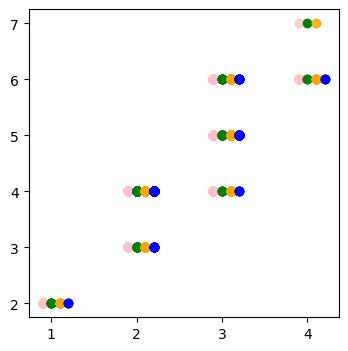

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for person in ["human", "random"]:
    outdegree_landmark_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_flowtrees,
        outdegree_non_landmark_flowtrees,
        normalise=False,
        group1_name="outdegree landmark",
        group2_name="outdegree not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    player_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_flowtrees,
        player_non_landmark_flowtrees,
        normalise=False,
        group1_name="player landmark",
        group2_name="player not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print(group1_features.shape)
    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "diameter",
    ]
    depths = np.concatenate((group1_features[:, 2], group2_features[:, 2]))
    avg_branching_factors = np.concatenate(
        (group1_features[:, 3], group2_features[:, 3])
    )

    ax.scatter(group2_features[:, 2] - 0.1, group2_features[:, 3], c="pink", alpha=0.5)
    ax.scatter(group1_features[:, 2], group1_features[:, 3], c="green")
    print(depths.shape)

    semantic_landmark_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_flowtrees,
        semantic_non_landmark_flowtrees,
        normalise=False,
        group1_name="semantic landmark",
        group2_name="semantic not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("semantic", person)
    print(
        results_df[results_df.p_value < 1][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    ax.scatter(
        group2_features[:, 2] + 0.1, group2_features[:, 3], c="orange", alpha=0.5
    )
    ax.scatter(group1_features[:, 2] + 0.2, group1_features[:, 3], c="blue")
    break

    print()
    print("----------------")
    print()
plt.show()

In [33]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),  # ← origin, not the data mean
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        **kwargs,
    )
    # no set_angle() — handled by the transform below

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    trans = (
        transforms.Affine2D()
        .rotate_deg(45)  # ← always 45° for the Pearson formulation
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)  # ← translation happens exactly once
    )
    ellipse.set_transform(trans + ax.transData)
    return ax.add_patch(ellipse)

[[17.         15.          2.          3.          8.5        12.        ]
 [19.         15.          2.          4.          5.25       12.        ]
 [19.         15.          3.          5.          5.25       10.        ]
 ...
 [18.         15.          2.          4.          6.33333333 11.        ]
 [17.         15.          2.          3.          8.5        12.        ]
 [18.         15.          2.          4.          6.33333333 12.        ]]
[[17.         15.          2.          3.          8.5        14.        ]
 [17.         15.          2.          3.          8.5        14.        ]
 [17.         15.          2.          3.          8.5        14.        ]
 ...
 [21.         15.          3.          5.          4.16666667 10.        ]
 [20.         15.          2.          4.          4.6        10.        ]
 [18.         15.          2.          4.          6.33333333 13.        ]]
[[19.         15.          2.          4.          5.25       12.        ]
 [18.        

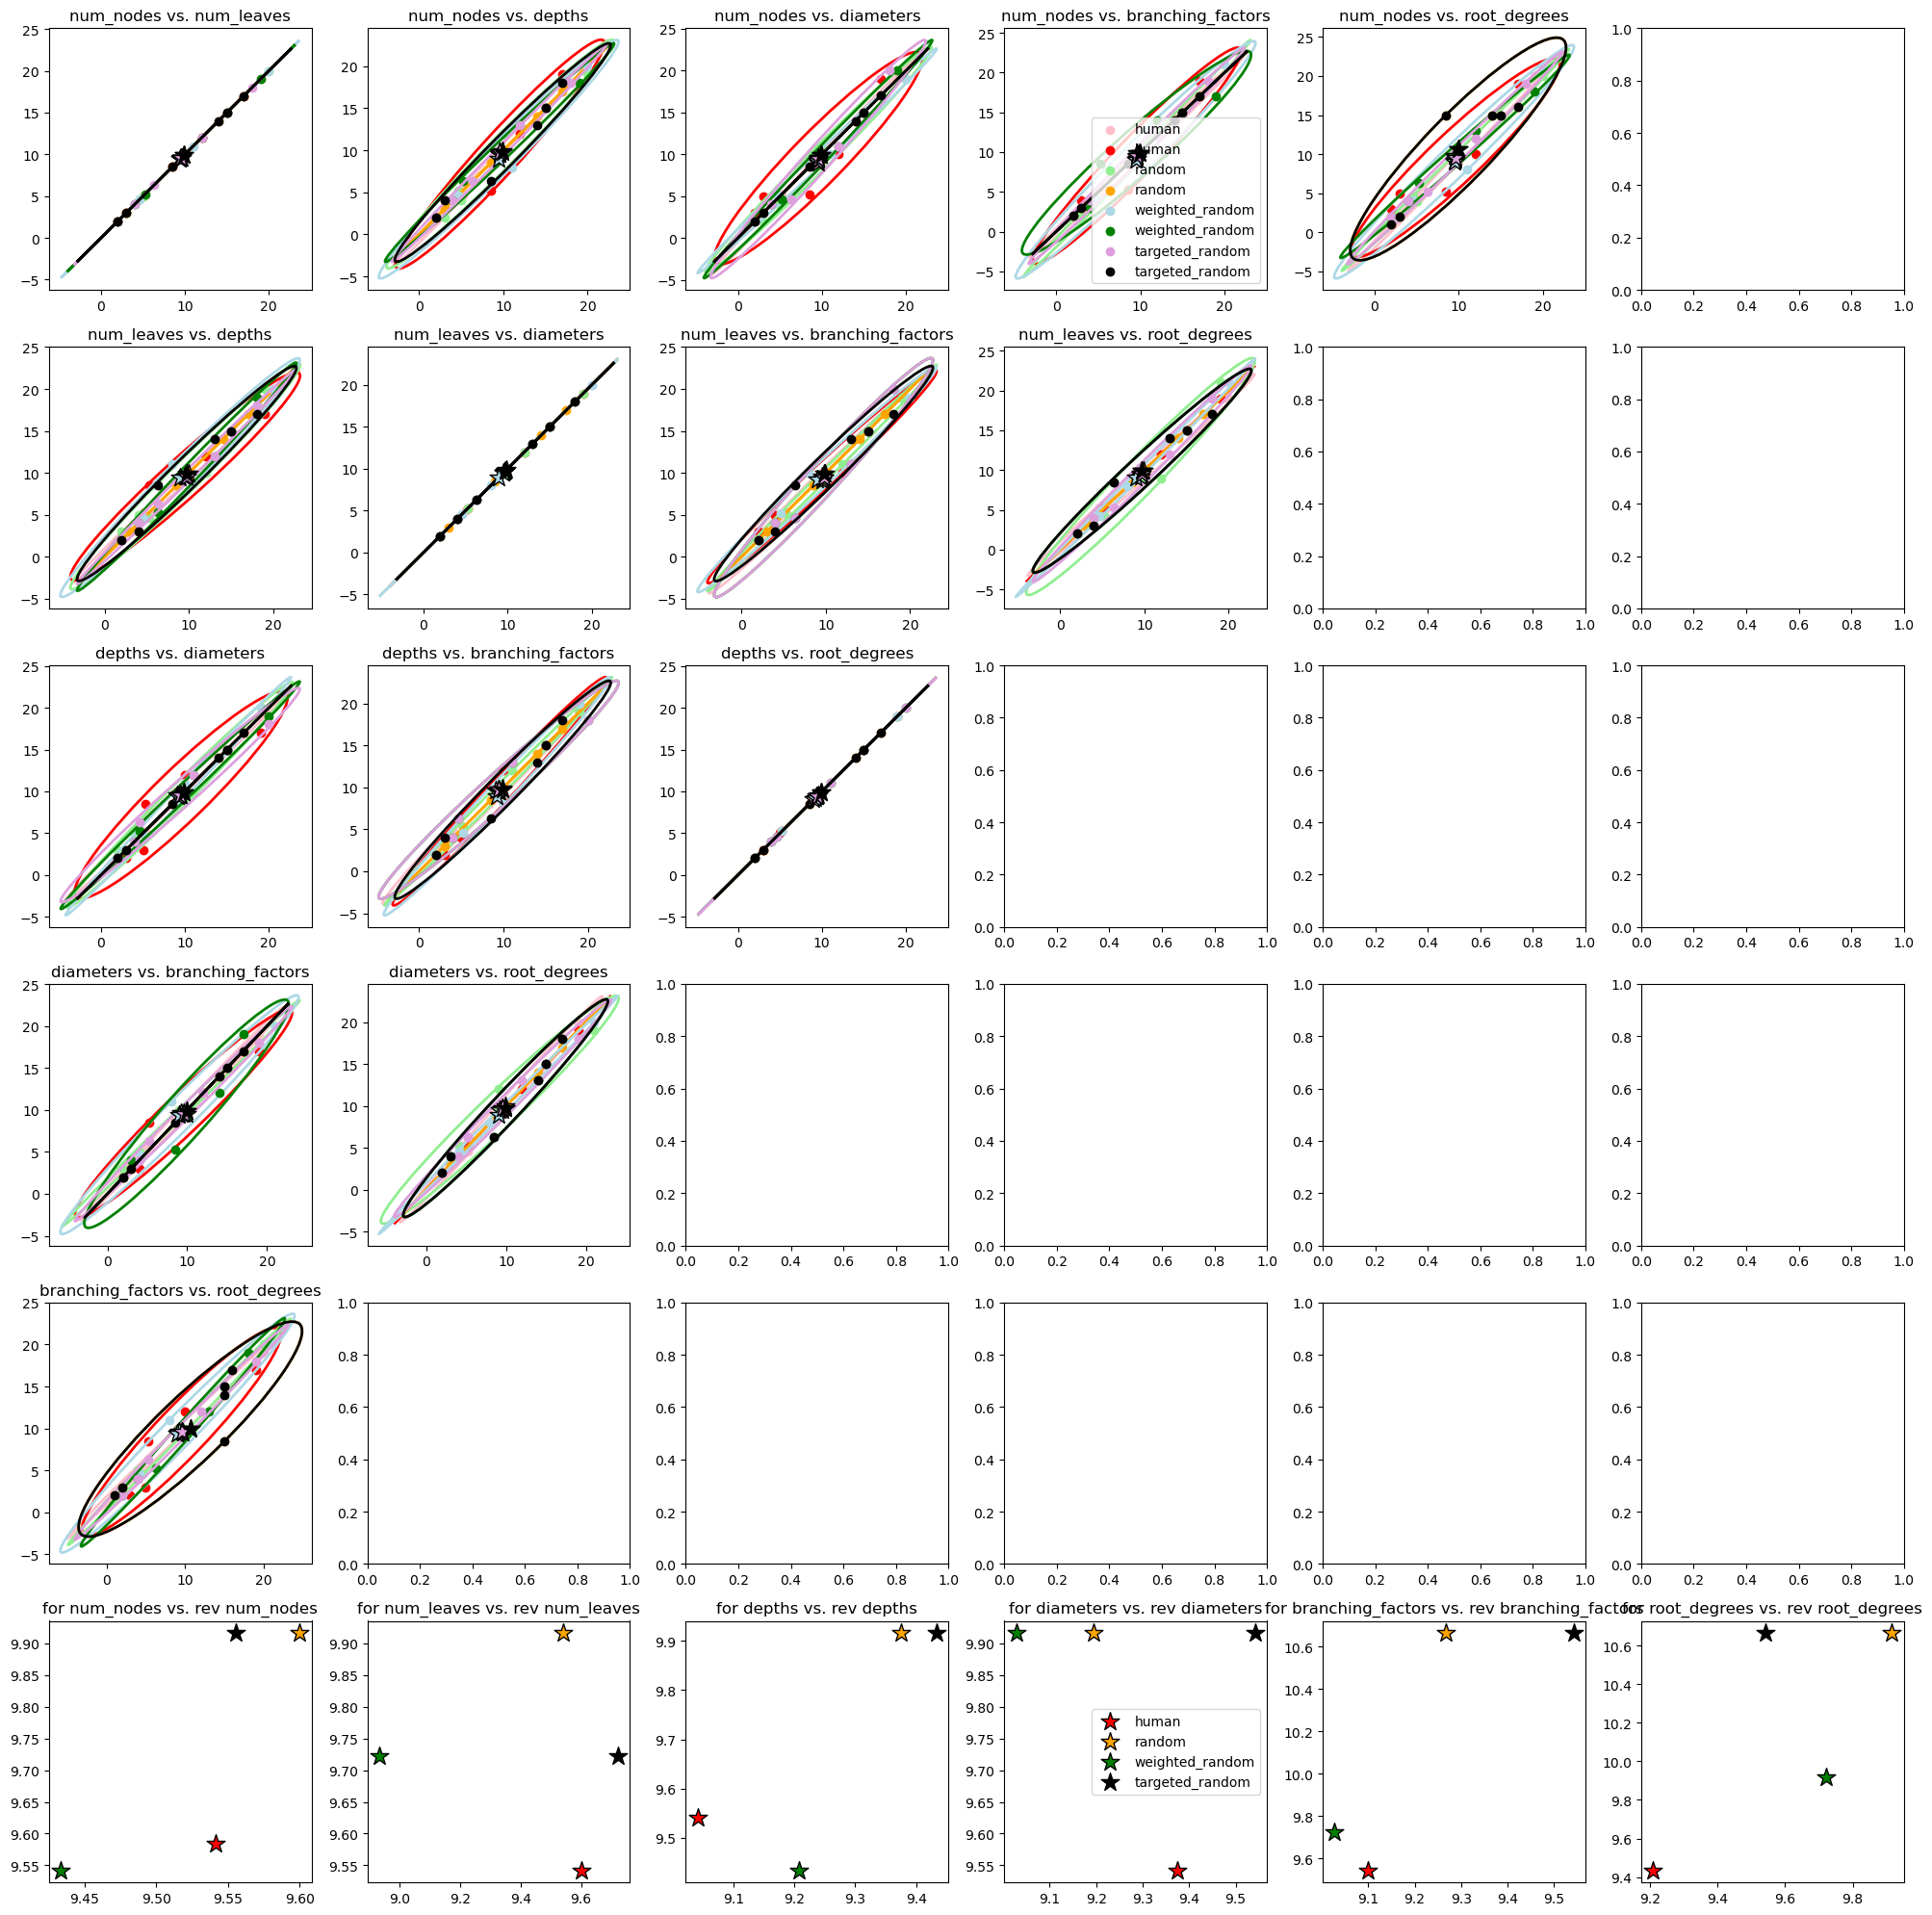

In [34]:
# Plot by all sorts of things!!
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
feature_names = [
    "num_nodes",
    "num_leaves",
    "depths",
    "diameters",
    "branching_factors",
    "root_degrees",
]
fig, axes = plt.subplots(6, 6, figsize=(20, 20))

for i, group in enumerate(["human", "random", "weighted_random", "targeted_random"]):
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    rev_features = np.array([extract_tree_features(G, 0) for G in rev_trees])
    print(rev_features)
    for_trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]
    for_features = np.array([extract_tree_features(G, 0) for G in for_trees])

    for ii, feats in enumerate([for_features, rev_features]):
        for j, feat1_name in enumerate(feature_names):
            for k, feat2_name in enumerate(feature_names[j + 1 :]):
                axes[j, k].scatter(
                    feats[j], feats[k], c=colors[i + 4 * ii], label=group
                )
                axes[j, k].scatter(
                    feats[j].mean(),
                    feats[k].mean(),
                    c=colors[i + 4 * ii],
                    alpha=1,
                    s=200,
                    marker="*",
                    edgecolors="black",
                    zorder=10,
                )
                confidence_ellipse(
                    feats[j],
                    feats[k],
                    axes[j, k],
                    n_std=2.0,
                    edgecolor=colors[i + 4 * ii],
                    facecolor="none",
                    linewidth=2,
                )
                axes[j, k].set_title(f"{feat1_name} vs. {feat2_name}")

    for j, feat_name in enumerate(feature_names):
        # axes[j, k].scatter(feats[j], feats[k], c=colors[i + 4 * ii], label=group)
        axes[-1, j].scatter(
            for_features[j].mean(),
            rev_features[j].mean(),
            c=colors[i + 4 * ii],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            zorder=10,
            label=group,
        )
        # confidence_ellipse(
        #     feats[j],
        #     feats[k],
        #     axes[j, k],
        #     n_std=2.0,
        #     edgecolor=colors[i + 4 * ii],
        #     facecolor="none",
        #     linewidth=2,
        # )
        axes[-1, j].set_title(f"for {feat_name} vs. rev {feat_name}")

axes[0, 3].legend()
axes[-1, 3].legend()
plt.tight_layout()
plt.show()


In [35]:
## feature pca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_dict = {}
labels_dict = {}
trees_dict = {}

for group in ["human", "random", "weighted_random", "targeted_random"]:
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]

    rev_features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )
    rev_labels = np.array(
        [
            "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    labels = np.array(
        [
            "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )

    features_dict[group] = features
    # features_dict["rev-"+group] = rev_features
    labels_dict[group] = labels
    # labels_dict["rev-"+group] = rev_labels
    trees_dict[group] = trees
    # trees_dict["rev-"+group] = rev_trees

all_features = np.concatenate(list(features_dict.values()))

scaler = StandardScaler()
all_scaled = scaler.fit_transform(all_features)

pca = PCA(n_components=3)  # 0.95

X_pca = pca.fit_transform(all_scaled)

print("Original shape:", all_scaled.shape)
print("Transformed shape:", X_pca.shape)
print("Number of components chosen:", pca.n_components_)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (10000, 6)
Transformed shape: (10000, 3)
Number of components chosen: 3
Explained variance ratio: [0.66024629 0.17167164 0.08757249]
Cumulative explained variance: 0.9194904189236711


[[ 9.03705740e-01  1.82899881e-01 -2.67540849e-01]
 [-4.49579458e-02  9.94603744e-01  6.25183904e-02]
 [ 8.29450851e-01 -6.13806297e-02  4.94605393e-01]
 [ 9.47079344e-01 -2.49919592e-02  2.05782799e-01]
 [-9.17315970e-01 -8.42161499e-04  2.09175568e-02]
 [-8.46612100e-01  5.52357743e-02  4.03214877e-01]]


NameError: name 'weights' is not defined

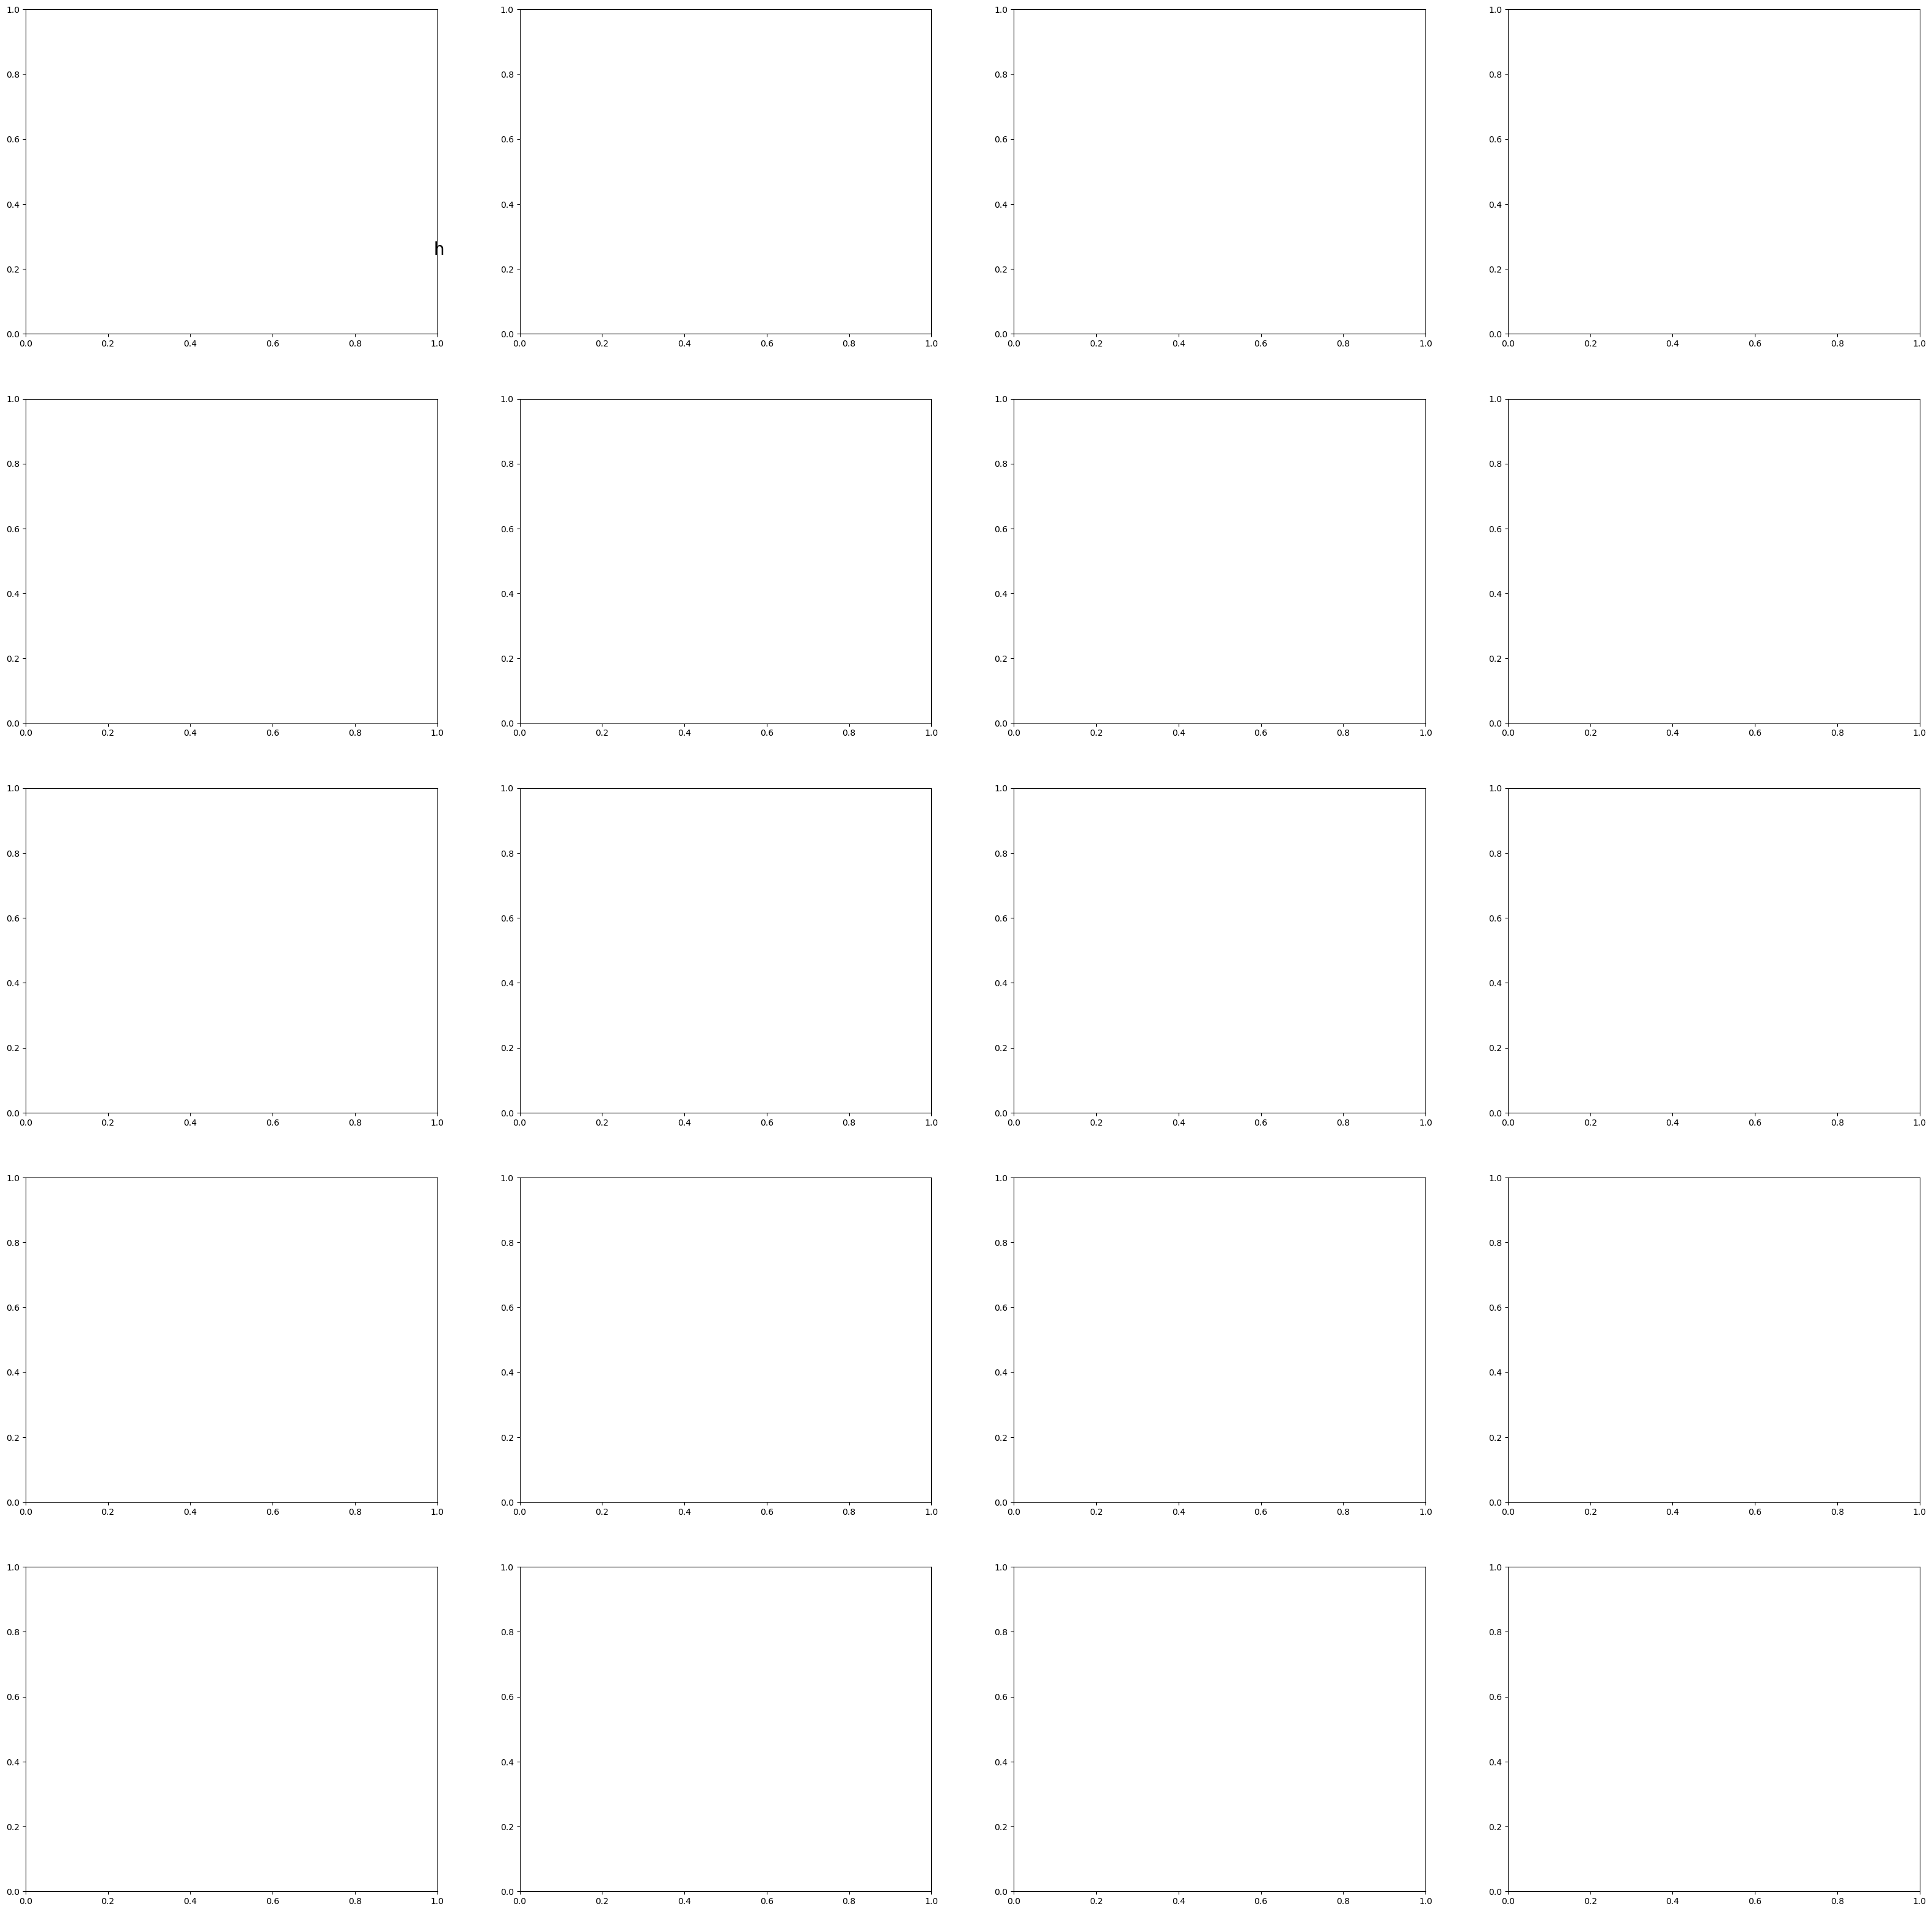

In [36]:
# pca_2d = PCA(n_components=2)
# X_pca_2d = pca_2d.fit_transform(X_scaled)
# n_group1 = human_features.shape[0]
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
print(loadings)
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
fig, axes = plt.subplots(5, 4, figsize=(40, 40))

ccs = ["red", "purple", "blue", "green", "yellow", "orange", "black", "grey"]
for j, group in enumerate(features_dict):
    # print(group)
    features = features_dict[group]
    labels = labels_dict[group]

    scaled_features = scaler.transform(features)
    featuers_pca = pca.transform(scaled_features)

    max_0_idx = np.argmax(featuers_pca[:, 0])
    min_0_idx = np.argmin(featuers_pca[:, 0])
    min_1_idx = np.argmin(featuers_pca[:, 1])
    outliers = [max_0_idx, min_0_idx, min_1_idx]

    for ii, idx in enumerate(outliers):
        feat = featuers_pca[idx, :]
        outlier_G = trees_dict[group][idx]
        axes[0, 0].annotate(
            group[0], (feat[0], feat[1]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        axes[0, 1].annotate(
            group[0], (feat[1], feat[2]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        axes[0, 2].annotate(
            group[0], (feat[2], feat[0]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        # plot_flow_tree(
        #     outlier_G,
        #     f"{group[0]} {ccs[ii]} outlier {feat} {group}",
        #     axes[ii + 2, j],
        #     just_edges=True,
        #     no_title=False,
        # )

    rand_idx = np.random.randint(len(scaled_features))
    feat = featuers_pca[rand_idx, :]
    outlier_G = trees_dict[group][rand_idx]
    axes[0, 0].annotate(
        group[0], (feat[0], feat[1]), c="black", alpha=1, fontsize=20, zorder=10
    )
    axes[0, 1].annotate(
        group[0], (feat[1], feat[2]), c="black", alpha=1, fontsize=20, zorder=10
    )
    axes[0, 2].annotate(
        group[0], (feat[2], feat[0]), c="black", alpha=1, fontsize=20, zorder=10
    )
    # plot_flow_tree(
    #     outlier_G,
    #     f"{group[0]} random attempt {feat} {group}",
    #     axes[1, j],
    #     just_edges=True,
    #     no_title=False,
    # )

    for i in range(3):
        ax = axes[0, i]
        jitter_width = 0.2
        n_group = len(features)

        slope = -weights[(i + 1) % 3] / weights[i]
        t = np.linspace(np.min(featuers_pca[:, i]), np.max(featuers_pca[:, i]), 100)
        line_y = slope * (t) + bias
        ax.plot(t, line_y)
        ax.scatter(
            featuers_pca[:, i]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            featuers_pca[:, (i + 1) % 3]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            c=[colors[j] if l == "landmark" else colors[j] for l in labels],
            alpha=0.3,
            s=15,
            label=group,
        )

        ax.scatter(
            featuers_pca[:, i].mean(),
            featuers_pca[:, (i + 1) % 3].mean(),
            c=colors[j],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            label=group,
            zorder=10,
        )

        confidence_ellipse(
            featuers_pca[:, i],
            featuers_pca[:, (i + 1) % 3],
            ax,
            n_std=2.0,
            edgecolor=colors[j],
            facecolor="none",
            linewidth=2,
            label="2 std dev",
        )

        # ax.scatter(featuers_pca[:, i][[l=="landmark" for l in labels]].mean(), featuers_pca[:, (i+1)%3][[l=="landmark" for l in labels]].mean(), c=colors[j], edgecolors='black', alpha=1, s=200, marker="^", label=group + " landmark", zorder=10)

for i in range(3):
    # Plot the loadings as arrows
    for j, feature in enumerate(feature_names):
        axes[0, i].arrow(
            -6, -4, loadings[j, i], loadings[j, (i + 1) % 3], color="k", alpha=0.7
        )
        axes[0, i].annotate(
            feature,
            (-6 + loadings[j, i] * 1.1, -4 + loadings[j, (i + 1) % 3] * 1.1),
            color="k",
            fontsize=8,
            ha="center",
            va="center",
        )

    axes[0, i].set_xlabel(f"PC{i} (var={pca.explained_variance_ratio_[i]:0.3f})")
    axes[0, i].set_ylabel(
        f"PC{(i + 1) % 3} (var={pca.explained_variance_ratio_[(i + 1) % 3]:0.3f})"
    )

axes[0, 2].legend()
plt.suptitle(
    f"3 Component PCA (explained var={np.sum(pca.explained_variance_ratio_):0.3f}) for node Flow Trees"
)
plt.tight_layout()
plt.show()


# num_nodes,
# num_leaves,
# depth,
# diameter,
# bf,
# rd,

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix


# Load an example dataset (Iris flower dataset)
X = []
y = []

for j, group in enumerate(features_dict):
    if j not in [0, 1, 2, 3]:
        continue
    features = features_dict[group]
    labels = labels_dict[group]

    scaled_features = scaler.transform(features)
    features_pca = pca.transform(scaled_features)
    X.extend(features_pca)
    for _ in range(features_pca.shape[0]):
        y.append(j > 0)

X = np.array(X)
y = np.array(y)

accs = []
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    )

    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy * 100:.2f}%")

    weights = svm_model.coef_[0]
    bias = svm_model.intercept_[0]
    print(weights, bias)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f1)
    cm = confusion_matrix(y_test, y_pred)

    accs.append(f1)

    print(cm)
print(np.mean(accs))

Model Accuracy: 79.55%
[-0.44435739  0.52254994 -0.36350318] 0.968826335361968
0.7758662895825718
[[ 176  300]
 [ 109 1415]]
Model Accuracy: 77.20%
[-0.4475239   0.61059017 -0.34445266] 0.9651735494037452
0.7467672418180893
[[ 179  349]
 [ 107 1365]]
Model Accuracy: 77.95%
[-0.45445321  0.61346009 -0.35186919] 0.9650971053945298
0.7559639037695768
[[ 166  329]
 [ 112 1393]]
Model Accuracy: 77.65%
[-0.45120387  0.52349802 -0.36956357] 0.9687962682296832
0.7561640261116779
[[ 169  318]
 [ 129 1384]]
Model Accuracy: 78.15%
[-0.44449922  0.52251646 -0.36365414] 0.9689085982285464
0.7595477436508223
[[ 185  327]
 [ 110 1378]]
0.7588618409865476


In [32]:
for person in ["human", "random"]:
    outdegree_landmark_rev_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_rev_flowtrees,
        outdegree_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="outdegree landmark rev",
        group2_name="outdegree not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_rev_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    player_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_rev_flowtrees,
        player_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="player landmark rev",
        group2_name="player not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    semantic_landmark_rev_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_rev_flowtrees,
        semantic_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="semantic landmark rev",
        group2_name="semantic not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev semantic", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print()
    print("----------------")
    print()

rev outdegree human
                 metric  group1_mean  group2_mean direction   p_value
0             num_nodes    17.556000    17.877778      less  0.000108
1            num_leaves    14.992000    14.948444      more  0.029944
2                 depth     1.956000     2.080444      less  0.000539
3  avg_branching_factor     8.041333     7.449089      more  0.002134
4              diameter     3.424000     3.656444      less  0.000078
rev player human
      metric  group1_mean  group2_mean direction   p_value
0  num_nodes       17.668    17.865333      less  0.017704
4   diameter        3.524     3.645333      less  0.039476
rev semantic human
                 metric  group1_mean  group2_mean direction   p_value
2                 depth     1.996000     2.076000      less  0.026212
3  avg_branching_factor     8.069995     7.445904      more  0.001210
4              diameter     3.500000     3.648000      less  0.011995

----------------

rev outdegree random
                 metric  gr

Outdegree landmarks:


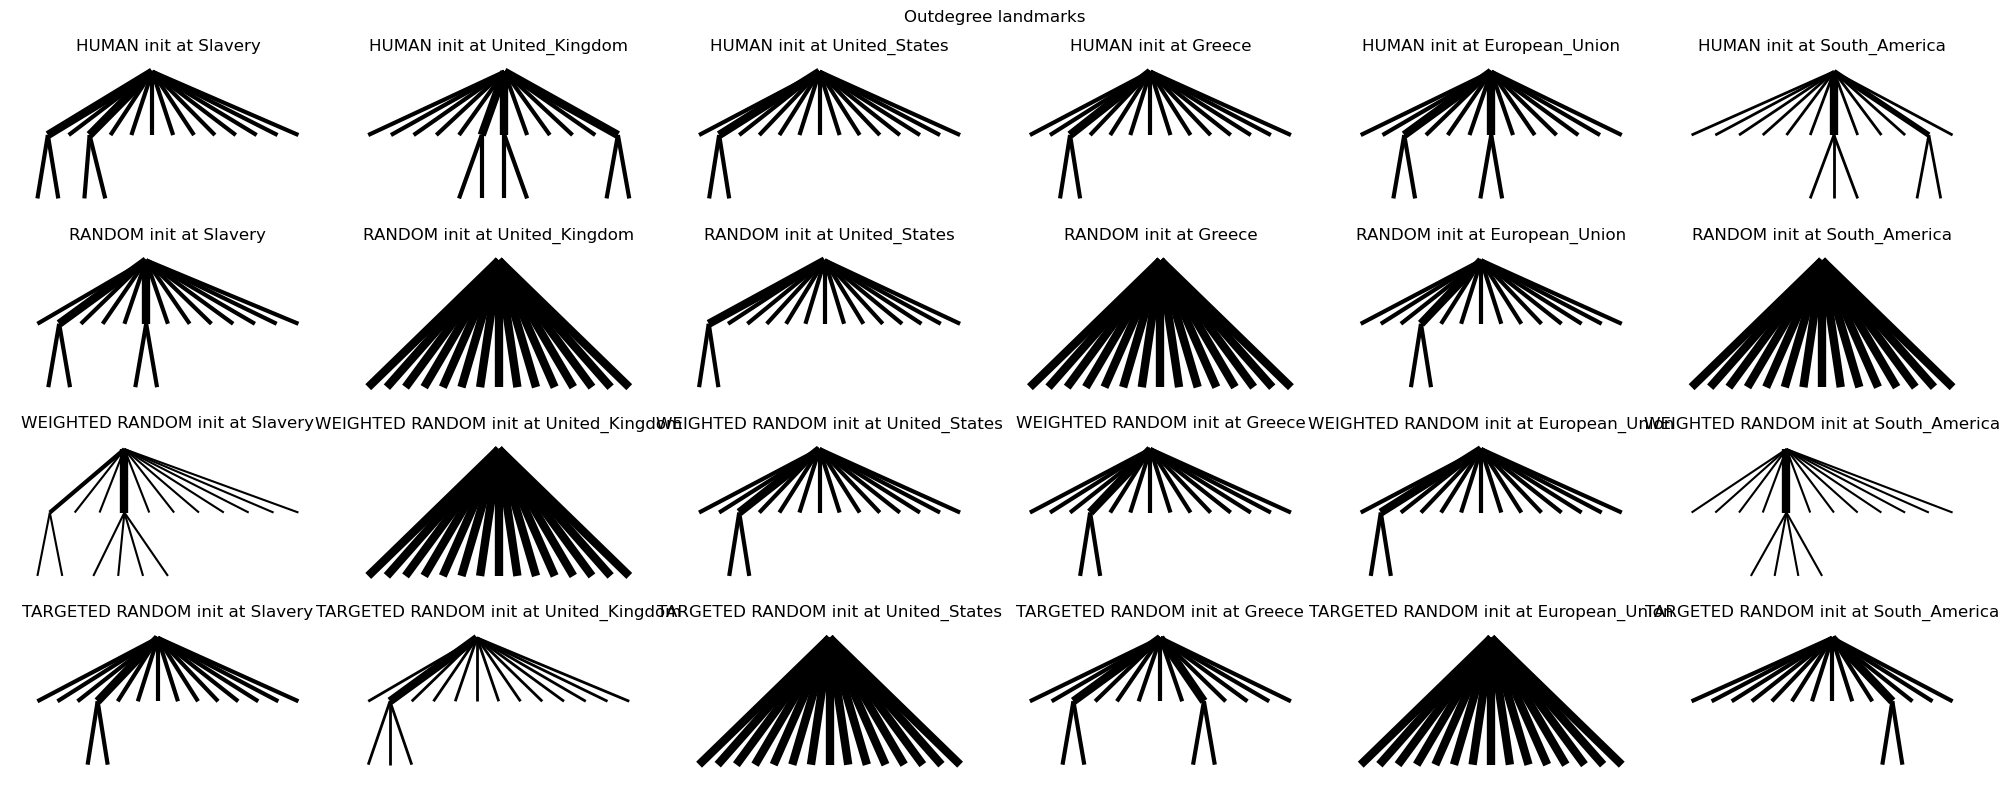

Outdegree not landmarks:


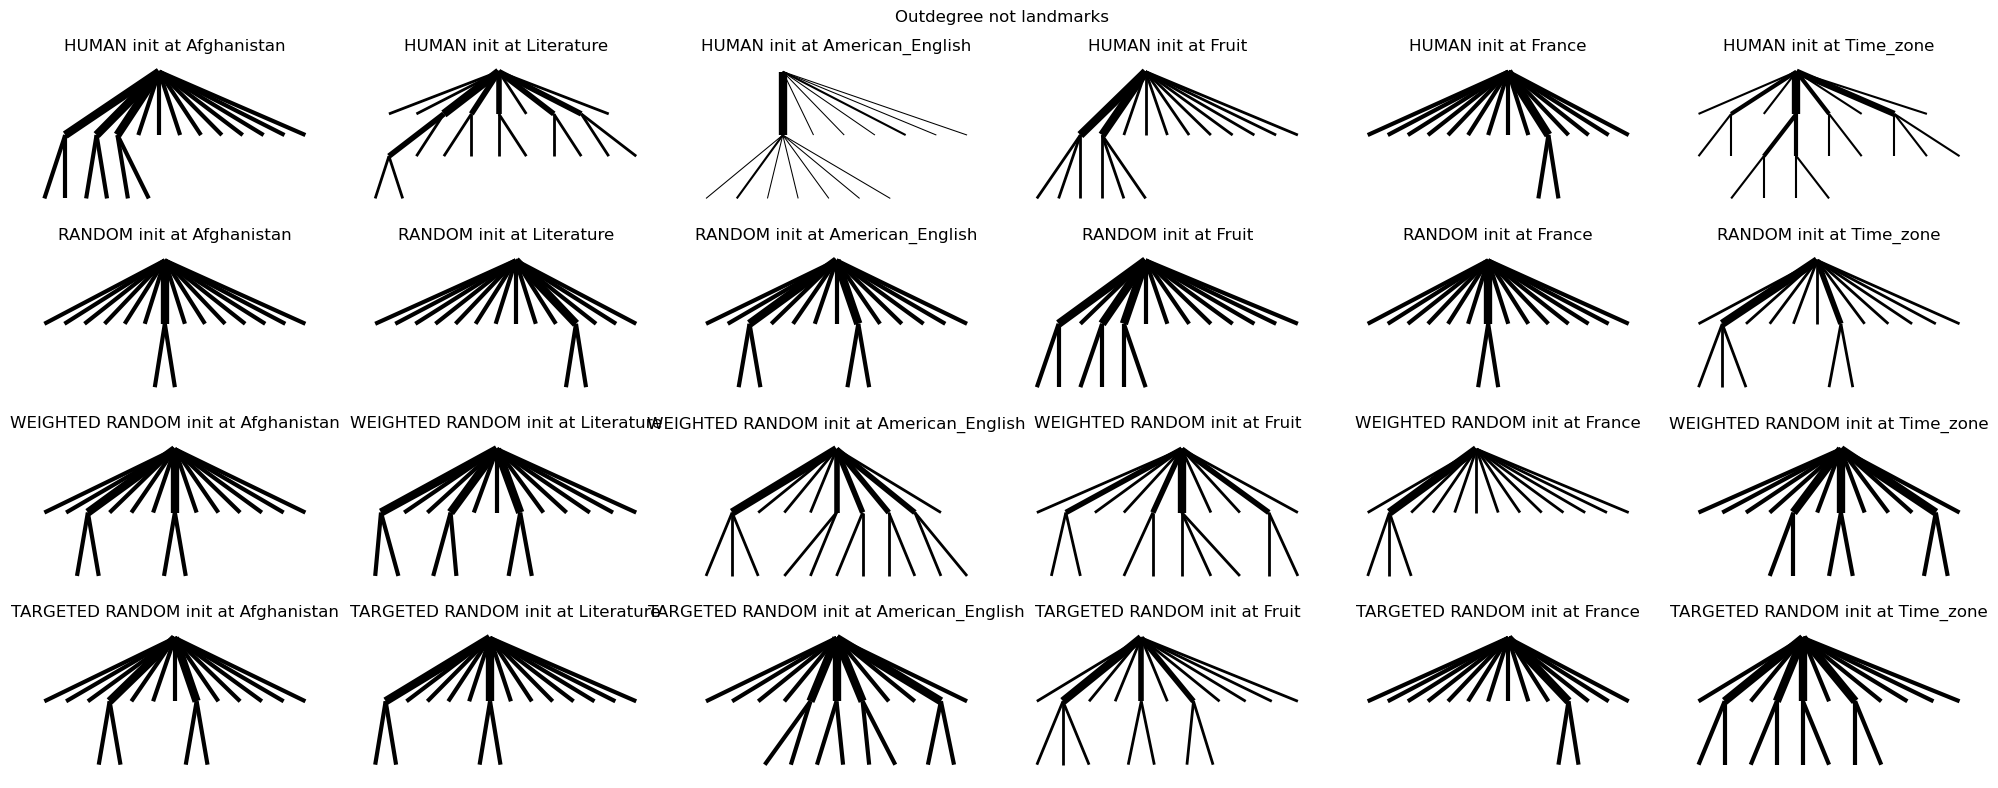

Player landmarks:


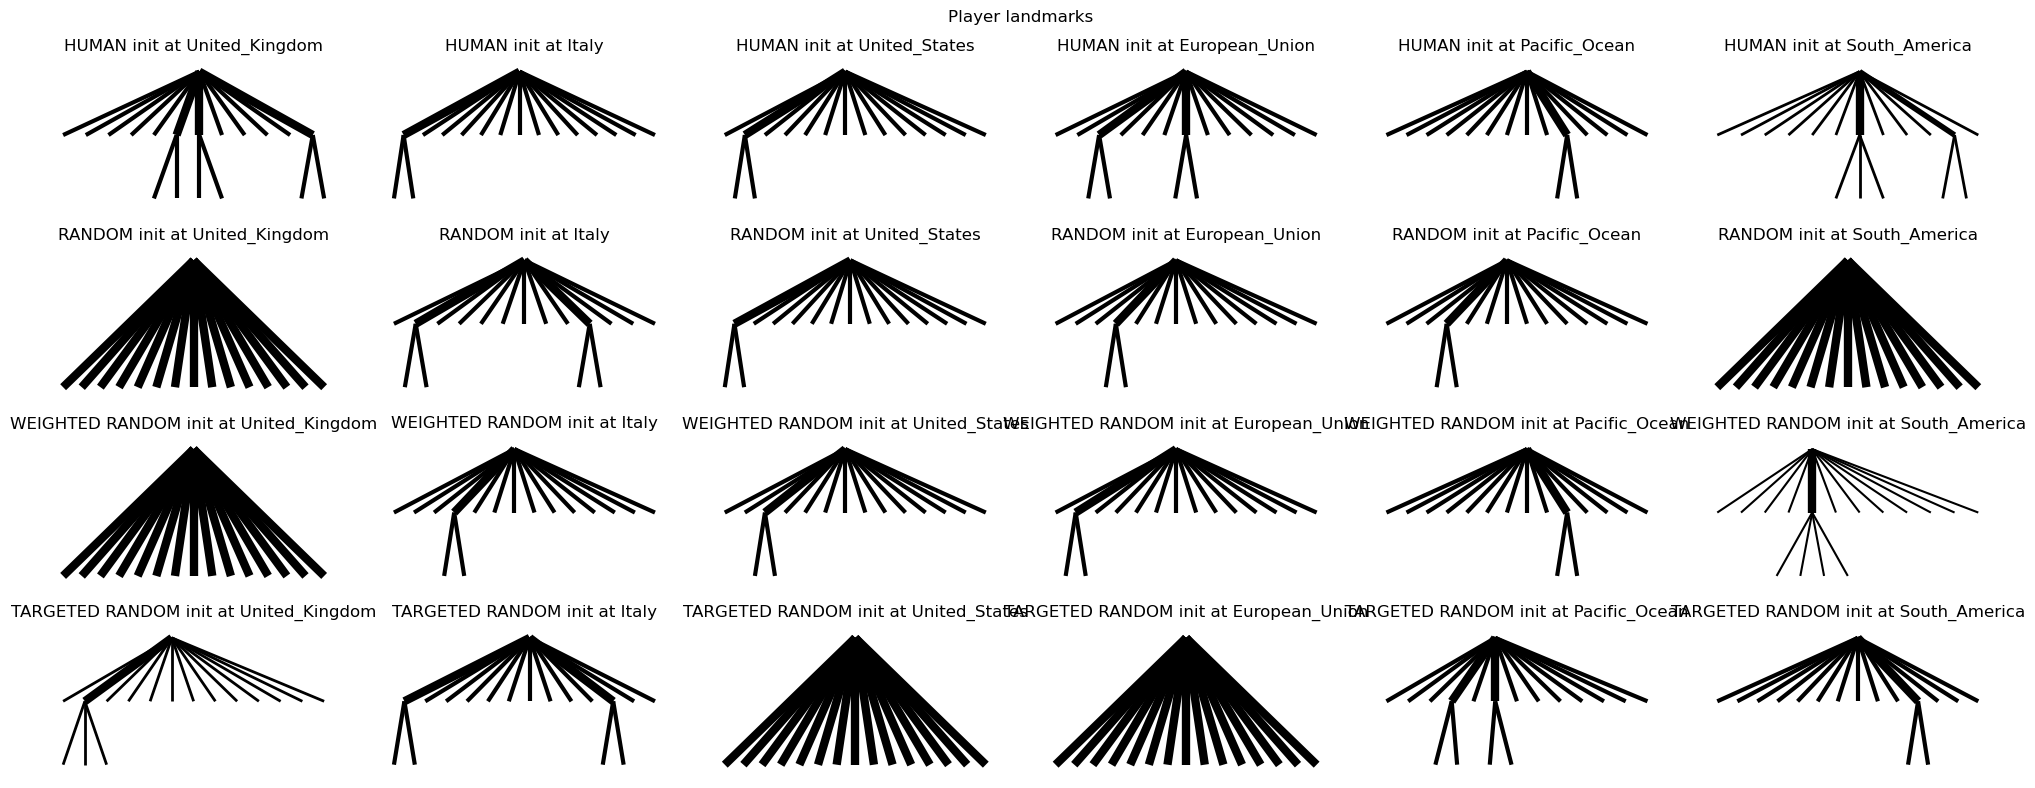

player not landmarks:


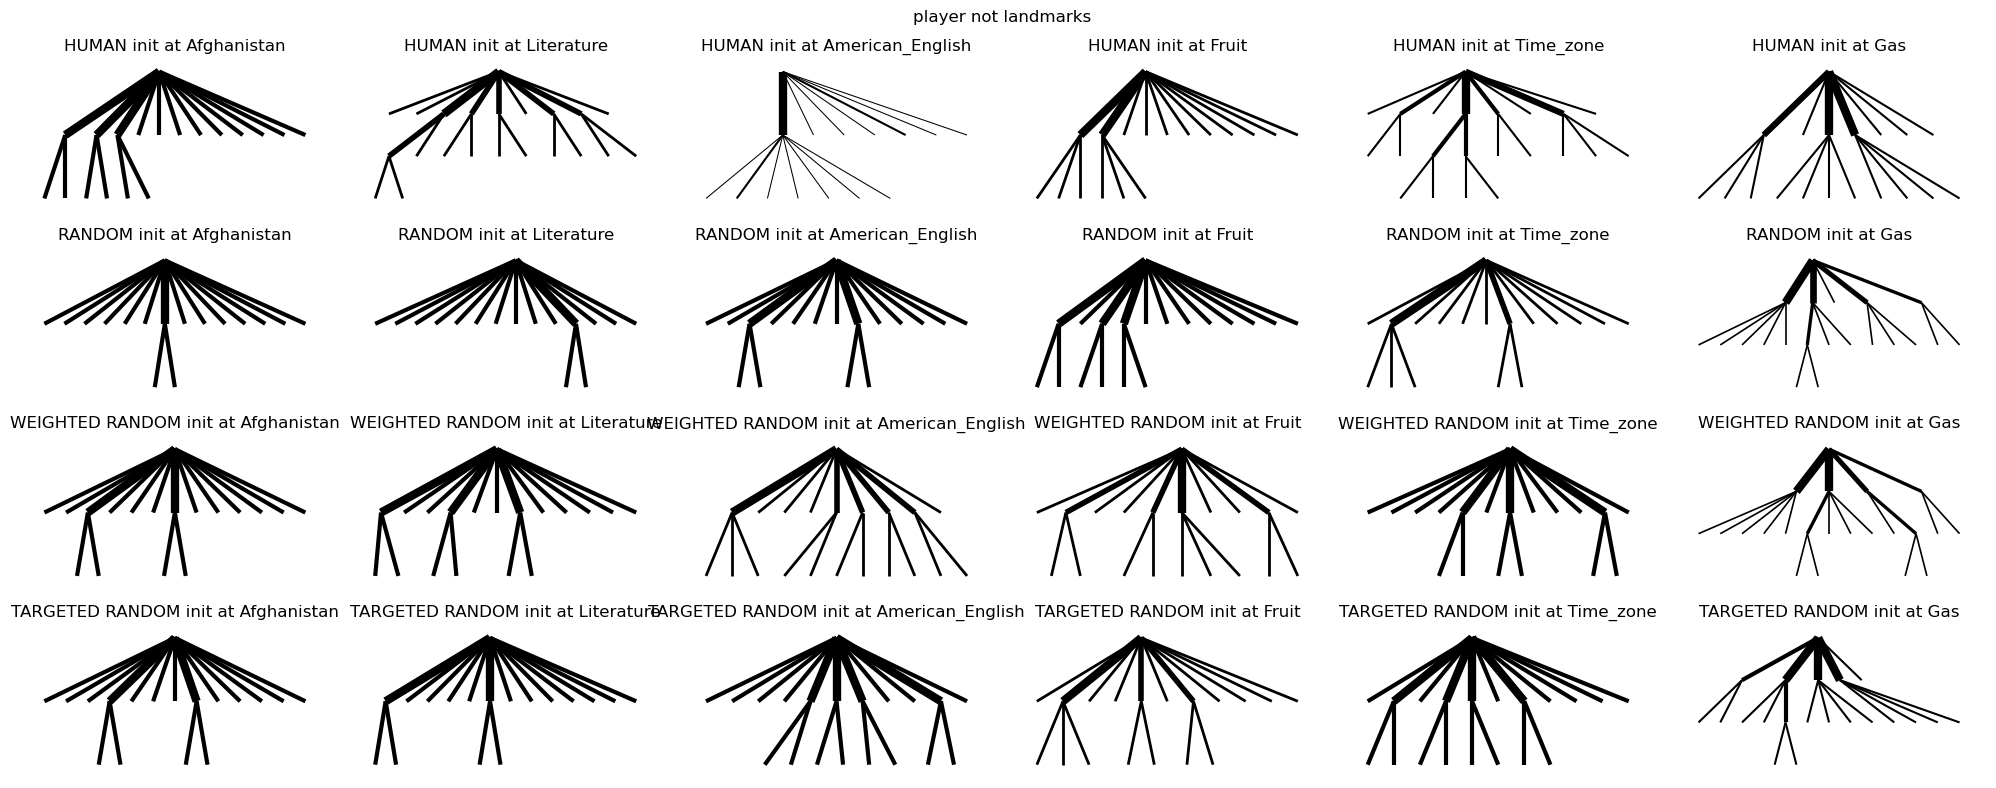

Semantic landmarks:


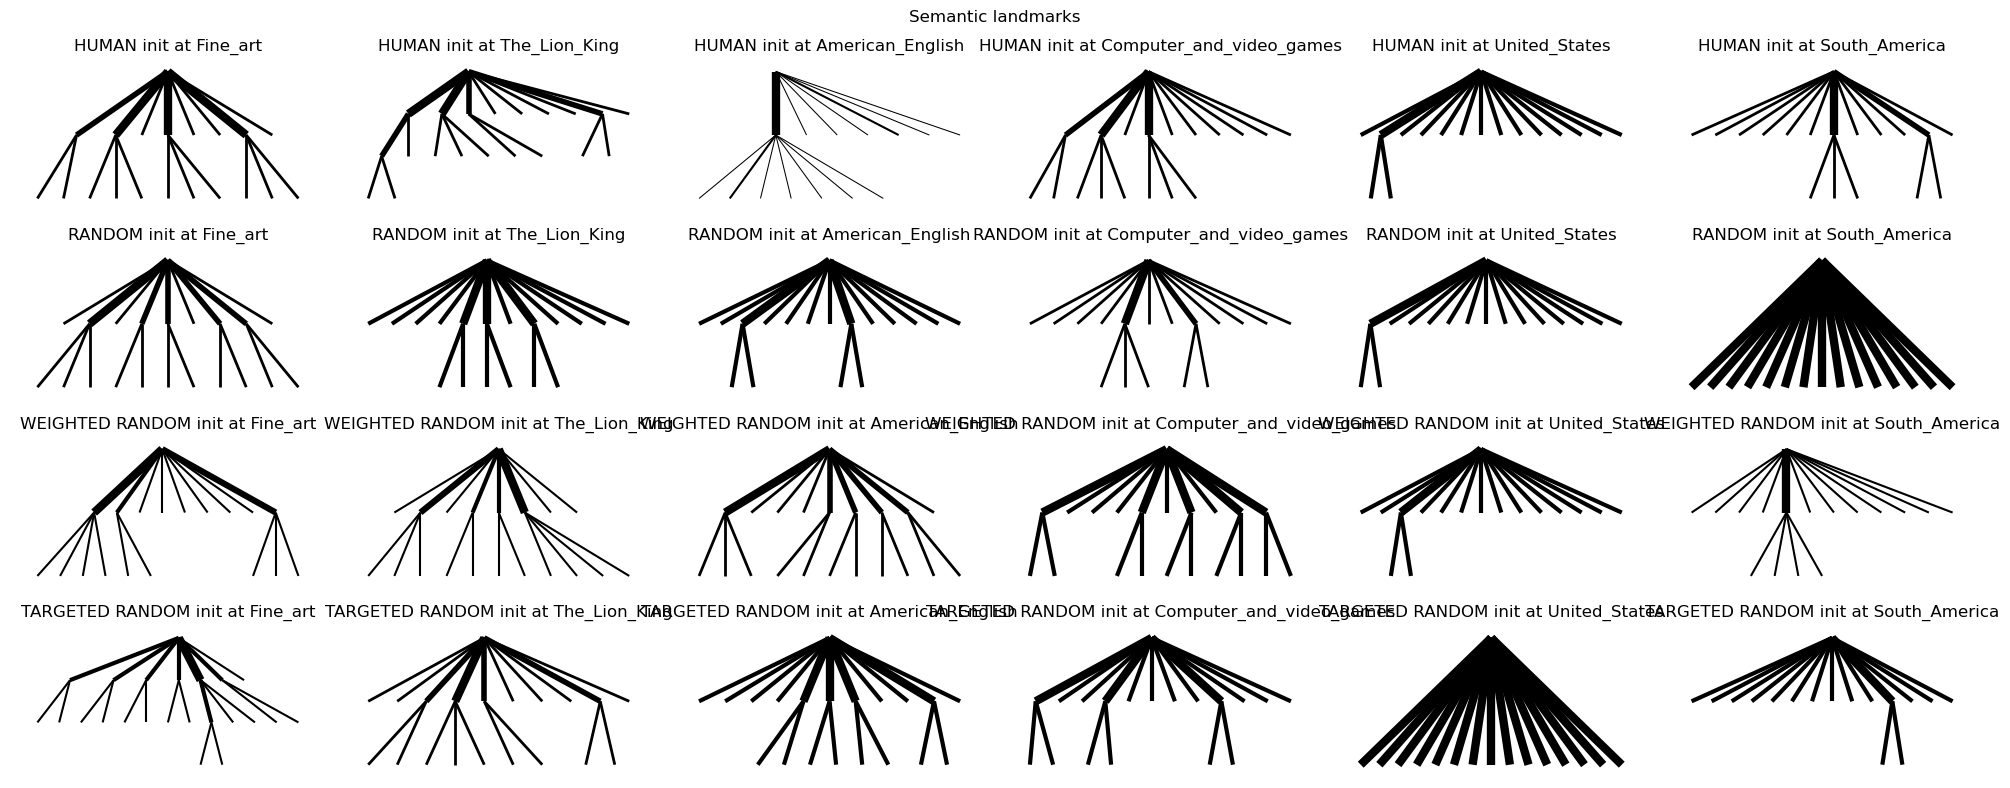

semantic not landmarks:


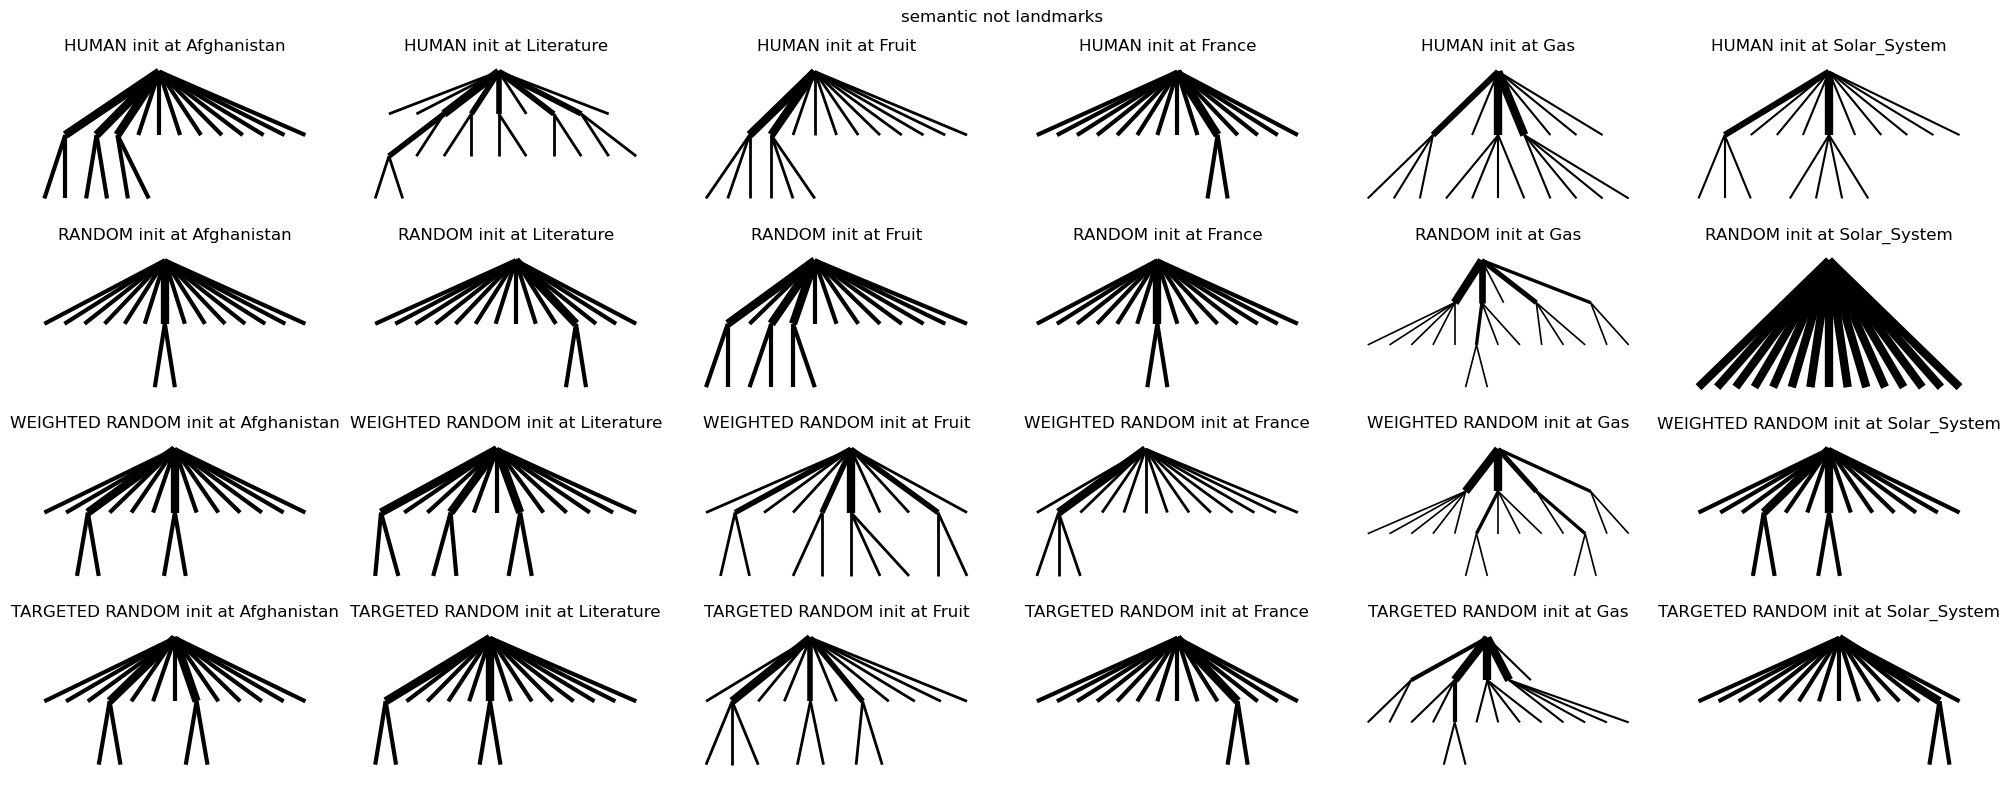

In [33]:
print("Outdegree landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in outdegree_landmarks},
    title_str="Outdegree landmarks",
)
print("Outdegree not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - outdegree_landmarks)
    },
    title_str="Outdegree not landmarks",
)
print("Player landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in player_landmarks},
    title_str="Player landmarks",
)
print("player not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - player_landmarks)
    },
    title_str="player not landmarks",
)
print("Semantic landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in semantic_landmarks},
    title_str="Semantic landmarks",
)
print("semantic not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - semantic_landmarks)
    },
    title_str="semantic not landmarks",
)
